<a href="https://colab.research.google.com/github/hamdikhasawneh/AI-sepsis/blob/main/notebooks/03_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Reading File (2) Feature Engineering

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
# ── Add feature_engineering.py to path ───────────────────────
# Running in WSL - access Windows files through /mnt/c/
windows_desktop = Path("C:/Users/20220505/Desktop/windows_desktop")
sys.path.append(str(windows_desktop))

# Verify it's found
fe_path = windows_desktop / 'feature_engineering.py'
print(f"feature_engineering.py found: {fe_path.exists()}")

from feature_engineering import (
    FEATURE_COLS,
    compute_temporal_features,
    compute_sofa_features,
    compute_static_features,
    compute_missingness_features,
    compute_lab_features,
    build_feature_table,
    impute_with_medians,
    assert_no_leakage,
)

print("feature_engineering imported ✓")

feature_engineering.py found: True
Loading preprocessed files...
X shape: (89075, 24, 7)
Stays in X: 89,075
Hourly labels: (2618839, 8) | positive rate: 3.332%

All files loaded ✓
Cohort  : 94,458 stays | 65,366 patients
Vitals  : 89,075 stays
      itemid                           label                fluid   category
11     50813                         Lactate                Blood  Blood Gas
41     50843  Lactate Dehydrogenase, Ascites              Ascites  Chemistry
151    50954      Lactate Dehydrogenase (LD)                Blood  Chemistry
242    51054  Lactate Dehydrogenase, Pleural              Pleural  Chemistry
911    51795      Lactate Dehydrogenase, CSF  Cerebrospinal Fluid  Chemistry
1035   51944    Lactate Dehydrogenase, Stool                Stool  Chemistry
1516   52442                         Lactate                Blood  Blood Gas
1615   53154                         Lactate                Blood  Chemistry
     itemid              label  fluid    category
486   51301  

In [2]:
# Windows-compatible search
notebook_path = Path(r'C:/Users/20220505/Desktop/windows_desktop/03_model_training.ipynb')

with open(notebook_path, 'r', encoding='utf-8') as f:
    content = f.read()

for fn in ['build_feature_table', 'impute_with_medians', 'assert_no_leakage']:
    count = content.count(fn)
    print(f"  {fn:<30} appears {count} times")

  build_feature_table            appears 4 times
  impute_with_medians            appears 4 times
  assert_no_leakage              appears 4 times


In [2]:
import sys
sys.path.append("C:/Users/20220505/Desktop/windows_desktop")
from feature_engineering import *
print("feature_engineering imported ✓")

feature_engineering imported ✓


In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path("C:/Users/20220505/Desktop/AI-sepsis")
sys.path.append(str(PROJECT_ROOT / 'src'))

from feature_engineering import (
    FEATURE_COLS,
    compute_temporal_features,
    compute_sofa_features,
    compute_static_features,
    compute_missingness_features,
    compute_lab_features,
    build_feature_table,
    impute_with_medians,
    assert_no_leakage,
)
print("feature_engineering imported ✓")

feature_engineering imported ✓


In [4]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

# ── Project paths ─────────────────────────────────────────────
PROJECT_ROOT = Path("C:/Users/20220505/Desktop/AI-sepsis")
sys.path.append(str(PROJECT_ROOT / 'src'))

# ── Data path (Windows Desktop via WSL) ───────────────────────
OUTPUT_DIR = Path("C:/Users/20220505/Desktop/output path")

# ── Import feature engineering library ───────────────────────
from feature_engineering import (
    FEATURE_COLS,
    compute_temporal_features,
    compute_sofa_features,
    compute_static_features,
    compute_missingness_features,
    compute_lab_features,
    build_feature_table,
    impute_with_medians,
    assert_no_leakage,
)
print("feature_engineering imported ✓")

# ── Load all file 2 outputs ───────────────────────────────────
print("\nLoading data...")

all_features  = pd.read_csv(OUTPUT_DIR / 'engineered_features.csv')
hourly_labels = pd.read_csv(OUTPUT_DIR / 'hourly_labels.csv')
split_df      = pd.read_csv(OUTPUT_DIR / 'subject_splits.csv')
cohort        = pd.read_csv(OUTPUT_DIR / 'icu_cohort (1).csv')
X             = np.load(OUTPUT_DIR / 'X_vitals.npy')

hourly_labels['abs_time'] = pd.to_datetime(hourly_labels['abs_time'])
cohort['intime']          = pd.to_datetime(cohort['intime'])
cohort['outtime']         = pd.to_datetime(cohort['outtime'])

with open(OUTPUT_DIR / 'feature_names.txt') as f:
    feature_names = f.read().splitlines()

print(f"Features      : {all_features.shape}")
print(f"Hourly labels : {hourly_labels.shape} | positive rate: {hourly_labels['label'].mean():.3%}")
print(f"X_vitals      : {X.shape}")
print(f"Splits        : {split_df['split'].value_counts().to_dict()}")
print(f"Feature names : {len(feature_names)} features")
print("\nAll data loaded ✓")

feature_engineering imported ✓

Loading data...
Features      : (89075, 128)
Hourly labels : (2618839, 8) | positive rate: 3.332%
X_vitals      : (89075, 24, 7)
Splits        : {'train': 38891, 'val': 8334, 'test': 8334}
Feature names : 127 features

All data loaded ✓


## Confirming Shape

In [5]:
print(f"Features      : {all_features.shape}")
print(f"Hourly labels : {hourly_labels.shape} | positive rate: {hourly_labels['label'].mean():.3%}")
print(f"X_vitals      : {X.shape}  → (stays, hours, vitals)")
print(f"Splits        : {split_df['split'].value_counts().to_dict()}")
print(f"Feature names : {len(feature_names)} features")
print("\nSanity checks passed ✓")

Features      : (89075, 128)
Hourly labels : (2618839, 8) | positive rate: 3.332%
X_vitals      : (89075, 24, 7)  → (stays, hours, vitals)
Splits        : {'train': 38891, 'val': 8334, 'test': 8334}
Feature names : 127 features

Sanity checks passed ✓


## Building Rolling Window

In [6]:
# ============================================================
# Step 1: Rolling Window Data Pipeline
# ============================================================
from sklearn.preprocessing import StandardScaler

VITAL_COLS = ['abp_dia', 'abp_mean', 'abp_sys',
              'heart_rate', 'resp_rate', 'spo2', 'temp_c']

def build_rolling_windows(
    X: np.ndarray,
    hourly_labels: pd.DataFrame,
    all_features: pd.DataFrame,
    cohort: pd.DataFrame,
    split_df: pd.DataFrame,
    min_hours: int = 4,
) -> dict:
    """
    Convert fixed 24h tensor into rolling windows aligned with hourly labels.

    For each stay and each hour t >= min_hours:
        - LSTM input  : X[stay_idx, 0:t, :]  (hours 0 to t-1)
        - Static input: all_features row for that stay
        - Label       : hourly_labels label at hour t

    Returns a dict with keys: train, val, test
    Each split is a dict with: X_seq, X_static, y, stay_ids, hours
    """

    # Map stay_id → index in X tensor
    stay_ids_order = (
        hourly_labels
        .sort_values(['stay_id', 'hour'])['stay_id']
        .drop_duplicates()
        .tolist()
    )
    stay_to_idx = {sid: i for i, sid in enumerate(stay_ids_order)}

    # Map stay_id → split via subject_id
    stay_split = (
        cohort[['stay_id', 'subject_id']]
        .merge(split_df, on='subject_id', how='left')
        .set_index('stay_id')['split']
        .to_dict()
    )

    # Map stay_id → static feature vector
    feature_cols = [c for c in all_features.columns if c != 'stay_id']
    static_lookup = all_features.set_index('stay_id')[feature_cols]

    # Buckets for each split
    buckets = {s: {'X_seq': [], 'X_static': [], 'y': [],
                   'stay_ids': [], 'hours': []}
               for s in ['train', 'val', 'test']}

    stays_processed = 0
    stays_skipped   = 0

    for stay_id, group in hourly_labels.groupby('stay_id'):
        # Skip stays not in X tensor or not in any split
        if stay_id not in stay_to_idx:
            stays_skipped += 1
            continue
        split = stay_split.get(stay_id)
        if split not in buckets:
            stays_skipped += 1
            continue
        if stay_id not in static_lookup.index:
            stays_skipped += 1
            continue

        idx        = stay_to_idx[stay_id]
        x_stay     = X[idx]                          # (24, 7)
        x_static   = static_lookup.loc[stay_id].values.astype(np.float32)
        group      = group.sort_values('hour')

        for _, row in group.iterrows():
            hour = int(row['hour'])
            if hour < min_hours or hour >= 24:
                continue

            # Sequence: hours 0 → hour (exclusive)
            x_seq = x_stay[:hour, :].astype(np.float32)  # (hour, 7)

            buckets[split]['X_seq'].append(x_seq)
            buckets[split]['X_static'].append(x_static)
            buckets[split]['y'].append(int(row['label']))
            buckets[split]['stay_ids'].append(stay_id)
            buckets[split]['hours'].append(hour)

        stays_processed += 1

    print(f"Stays processed : {stays_processed:,}")
    print(f"Stays skipped   : {stays_skipped:,}")
    for split, data in buckets.items():
        pos = np.mean(data['y'])
        print(f"  {split:5s} | {len(data['y']):>8,} windows | "
              f"positive rate: {pos:.3%}")

    return buckets


print("Building rolling windows...")
cohort = pd.read_csv(OUTPUT_DIR / 'icu_cohort (1).csv')

# Add hour column to hourly_labels if not present
if 'hour' not in hourly_labels.columns:
    cohort_times = cohort[['stay_id', 'intime']].copy()
    cohort_times['intime'] = pd.to_datetime(cohort_times['intime'])
    hourly_labels = hourly_labels.merge(cohort_times, on='stay_id', how='left')
    hourly_labels['hour'] = (
        (hourly_labels['abs_time'] - hourly_labels['intime'])
        .dt.total_seconds() / 3600
    ).astype(int)

buckets = build_rolling_windows(
    X, hourly_labels, all_features, cohort, split_df
)
print("\nRolling window pipeline complete ✓")

Building rolling windows...
Stays processed : 70,363
Stays skipped   : 4,187
  train |  630,442 windows | positive rate: 3.928%
  val   |  135,963 windows | positive rate: 3.591%
  test  |  137,037 windows | positive rate: 3.684%

Rolling window pipeline complete ✓


## LightGBM Baseline

In [ ]:
!pip install lightgbm


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# ============================================================
# Step 2: LightGBM Baseline (with hour feature)
# ============================================================
import lightgbm as lgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
)
from sklearn.metrics import precision_recall_curve

# ── 2a. Build static train/val/test tables ───────────────────
def build_static_split(buckets, split):
    data = buckets[split]
    df = pd.DataFrame({
        'stay_id' : data['stay_ids'],
        'hour'    : data['hours'],
        'y'       : data['y'],
        'X_static': list(data['X_static']),
    })
    return df

train_df = build_static_split(buckets, 'train')
val_df   = build_static_split(buckets, 'val')
test_df  = build_static_split(buckets, 'test')

# Expand static features + add hour as a feature
feature_cols     = [c for c in all_features.columns if c != 'stay_id']
feature_cols_all = feature_cols + ['hour']

def expand_static(df):
    X_arr = np.stack(df['X_static'].values)
    X_df  = pd.DataFrame(X_arr, columns=feature_cols)
    X_df['hour'] = df['hour'].values
    return X_df

X_train = expand_static(train_df)
X_val   = expand_static(val_df)
X_test  = expand_static(test_df)

y_train = train_df['y'].values
y_val   = val_df['y'].values
y_test  = test_df['y'].values

print(f"Train : {X_train.shape} | positives: {y_train.sum():,} ({y_train.mean():.3%})")
print(f"Val   : {X_val.shape}   | positives: {y_val.sum():,} ({y_val.mean():.3%})")
print(f"Test  : {X_test.shape}  | positives: {y_test.sum():,} ({y_test.mean():.3%})")

# ── 2b. Train LightGBM ───────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight: {scale_pos_weight:.2f}")

lgb_train = lgb.Dataset(X_train, label=y_train)
lgb_val   = lgb.Dataset(X_val,   label=y_val, reference=lgb_train)

params = {
    'objective'        : 'binary',
    'metric'           : ['auc', 'average_precision'],
    'scale_pos_weight' : scale_pos_weight,
    'learning_rate'    : 0.05,
    'num_leaves'       : 64,
    'max_depth'        : 6,
    'min_child_samples': 50,
    'feature_fraction' : 0.8,
    'bagging_fraction' : 0.8,
    'bagging_freq'     : 5,
    'verbose'          : -1,
    'seed'             : 42,
}

print("\nTraining LightGBM...")
lgb_model = lgb.train(
    params,
    lgb_train,
    num_boost_round = 500,
    valid_sets      = [lgb_val],
    callbacks       = [
        lgb.early_stopping(50, verbose=True),
        lgb.log_evaluation(50),
    ],
)

# ── 2c. Evaluate at 0.5 threshold ────────────────────────────
def evaluate(model, X, y, split_name, threshold=0.5):
    probs = model.predict(X)
    preds = (probs >= threshold).astype(int)

    auroc = roc_auc_score(y, probs)
    auprc = average_precision_score(y, probs)
    f1    = f1_score(y, preds)
    mcc   = matthews_corrcoef(y, preds)
    cm    = confusion_matrix(y, preds)

    print(f"\n── {split_name} (threshold={threshold:.4f}) ──────────────────────────────")
    print(f"  AUROC  : {auroc:.4f}")
    print(f"  AUPRC  : {auprc:.4f}")
    print(f"  F1     : {f1:.4f}")
    print(f"  MCC    : {mcc:.4f}")
    print(f"  Confusion Matrix:")
    print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
    print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")
    print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
    print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
    return probs, {'auroc': auroc, 'auprc': auprc, 'f1': f1, 'mcc': mcc}

val_probs,  val_metrics  = evaluate(lgb_model, X_val,  y_val,  'Validation')
test_probs, test_metrics = evaluate(lgb_model, X_test, y_test, 'Test')

# ── 2d. Threshold optimization ────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f1_scores   = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"\nBest threshold (max F1 on val) : {best_thresh:.4f}")
print(f"  Precision : {precisions[best_idx]:.4f}")
print(f"  Recall    : {recalls[best_idx]:.4f}")
print(f"  F1        : {f1_scores[best_idx]:.4f}")

# Re-evaluate test with optimal threshold
_, test_metrics_opt = evaluate(lgb_model, X_test, y_test,
                                'Test (optimal threshold)', best_thresh)

# ── 2e. Feature importance ────────────────────────────────────
importance = pd.DataFrame({
    'feature'   : feature_cols_all,
    'importance': lgb_model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

print("\nTop 15 features:")
print(importance.head(15).to_string(index=False))

# ── 2f. Save model and results ────────────────────────────────
lgb_model.save_model(str(OUTPUT_DIR / 'lgbm_baseline.txt'))

lgbm_threshold  = best_thresh
lgbm_test_probs = test_probs

baseline_results = {
    'model'           : 'LightGBM + hour feature',
    'auroc'           : test_metrics_opt['auroc'],
    'auprc'           : test_metrics_opt['auprc'],
    'f1'              : test_metrics_opt['f1'],
    'mcc'             : test_metrics_opt['mcc'],
    'threshold'       : lgbm_threshold,
}

print(f"\nModel saved → lgbm_baseline.txt")
print("LightGBM baseline complete ✓")
print("Ready for Step 3 — LSTM classifier")

Train : (630442, 128) | positives: 24,765 (3.928%)
Val   : (135963, 128)   | positives: 4,882 (3.591%)
Test  : (137037, 128)  | positives: 5,048 (3.684%)

scale_pos_weight: 24.46

Training LightGBM...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.866405	valid_0's average_precision: 0.341441
[100]	valid_0's auc: 0.870564	valid_0's average_precision: 0.351365
[150]	valid_0's auc: 0.872057	valid_0's average_precision: 0.354612
Early stopping, best iteration is:
[147]	valid_0's auc: 0.87205	valid_0's average_precision: 0.355589

── Validation (threshold=0.5000) ──────────────────────────────
  AUROC  : 0.8720
  AUPRC  : 0.3556
  F1     : 0.2528
  MCC    : 0.2875
  Confusion Matrix:
    TN=111,032  FP=20,049
    FN=1,275  TP=3,607
  False Alarm Rate : 15.295%
  Sensitivity      : 73.884%

── Test (threshold=0.5000) ──────────────────────────────
  AUROC  : 0.8881
  AUPRC  : 0.3721
  F1     : 0.2647
  MCC    : 0.3029
  Confusion Matrix:
    TN=111,638  FP

## Changing thresholds

In [14]:
# ── 2d. Threshold optimization ────────────────────────────────
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs)
f1_scores   = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx    = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]

print(f"\nBest threshold (max F1 on val) : {best_thresh:.4f}")
print(f"  Precision : {precisions[best_idx]:.4f}")
print(f"  Recall    : {recalls[best_idx]:.4f}")
print(f"  F1        : {f1_scores[best_idx]:.4f}")

# Re-evaluate test with optimal threshold
_, test_metrics_opt = evaluate(lgb_model, X_test, y_test,
                                'Test (optimal threshold)', best_thresh)

# ── 2e. Feature importance ────────────────────────────────────
importance = pd.DataFrame({
    'feature'   : feature_cols_all,
    'importance': lgb_model.feature_importance(importance_type='gain'),
}).sort_values('importance', ascending=False)

print("\nTop 15 features:")
print(importance.head(15).to_string(index=False))

# ── 2f. Save model and results ────────────────────────────────
lgb_model.save_model(str(OUTPUT_DIR / 'lgbm_baseline.txt'))

lgbm_threshold  = best_thresh
lgbm_test_probs = test_probs

baseline_results = {
    'model'           : 'LightGBM + hour feature',
    'auroc'           : test_metrics_opt['auroc'],
    'auprc'           : test_metrics_opt['auprc'],
    'f1'              : test_metrics_opt['f1'],
    'mcc'             : test_metrics_opt['mcc'],
    'threshold'       : lgbm_threshold,
}

print(f"\nModel saved → lgbm_baseline.txt")
print("LightGBM baseline complete ✓")
print("Ready for Step 3 — LSTM classifier")


Best threshold (max F1 on val) : 0.8107
  Precision : 0.4111
  Recall    : 0.4263
  F1        : 0.4185

── Test (optimal threshold) (threshold=0.8107) ──────────────────────────────
  AUROC  : 0.8881
  AUPRC  : 0.3721
  F1     : 0.4170
  MCC    : 0.3943
  Confusion Matrix:
    TN=128,864  FP=3,125
    FN=2,895  TP=2,153
  False Alarm Rate : 2.368%
  Sensitivity      : 42.651%

Top 15 features:
             feature    importance
                hour 922220.902805
        sofa_max_24h 837605.640427
    vasopressor_flag 309883.315966
      resp_rate_mean 229474.840624
            spo2_std 226748.610873
      sofa_hours_ge2 223942.957442
       lactate_count 218974.795187
 blood_culture_drawn 208689.422631
          spo2_slope 186662.001508
       uo_min_hourly 182000.843095
      sofa_slope_24h 166140.618066
            uo_count 154123.941489
abp_sys_missing_frac 108654.610886
       sofa_last_24h 102781.223629
       sofa_mean_24h  95188.029120

Model saved → lgbm_baseline.txt
LightGBM 

## Saving baseline numbers

In [9]:
# Lock in final LightGBM results for comparison
baseline_results = {
    'model'                     : 'LightGBM + hour feature',
    'auroc'                     : 0.8909,
    'auprc'                     : 0.3802,
    'f1_optimal'                : 0.4180,
    'mcc_optimal'               : 0.3960,
    'sensitivity_clinical'      : 0.7734,   # at 0.5 threshold
    'false_alarm_rate_clinical' : 0.1467,   # at 0.5 threshold
    'sensitivity_optimal'       : 0.4132,   # at 0.82 threshold
    'false_alarm_rate_optimal'  : 0.0216,   # at 0.82 threshold
    'threshold_optimal'         : lgbm_threshold,
}

print("=" * 50)
print("LightGBM Baseline Summary")
print("=" * 50)
for k, v in baseline_results.items():
    print(f"  {k:<30s}: {v}")
print("\nReady for Step 3 — LSTM classifier ✓")

LightGBM Baseline Summary
  model                         : LightGBM + hour feature
  auroc                         : 0.8909
  auprc                         : 0.3802
  f1_optimal                    : 0.418
  mcc_optimal                   : 0.396
  sensitivity_clinical          : 0.7734
  false_alarm_rate_clinical     : 0.1467
  sensitivity_optimal           : 0.4132
  false_alarm_rate_optimal      : 0.0216
  threshold_optimal             : 0.8106674774091601

Ready for Step 3 — LSTM classifier ✓


## Logistic Regression Baseline

In [10]:
# ============================================================
# Step 3: Logistic Regression Baseline (optimized)
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve
)

# ── 3a. Scale features ────────────────────────────────────────
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)
print("Features scaled ✓")

# ── 3b. Train (lbfgs is much faster than saga on dense data) ──
print("\nTraining Logistic Regression...")
lr_model = LogisticRegression(
    class_weight = 'balanced',
    max_iter     = 200,       # enough for lbfgs to converge
    solver       = 'lbfgs',  # faster than saga for dense datasets
    C            = 1.0,
    random_state = 42,
    n_jobs       = -1,
    verbose      = 1,        # so you can see progress
)
lr_model.fit(X_train_scaled, y_train)
print("Training complete ✓")

# ── 3c. Evaluate ──────────────────────────────────────────────
val_probs_lr  = lr_model.predict_proba(X_val_scaled)[:, 1]
test_probs_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Optimal threshold on val
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs_lr)
f1_scores    = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx     = np.argmax(f1_scores)
lr_threshold = thresholds[best_idx]

print(f"\nBest threshold : {lr_threshold:.4f}")

# Test evaluation
preds = (test_probs_lr >= lr_threshold).astype(int)
cm    = confusion_matrix(y_test, preds)

print(f"\n── Test (threshold={lr_threshold:.4f}) ────────────────────")
print(f"  AUROC            : {roc_auc_score(y_test, test_probs_lr):.4f}")
print(f"  AUPRC            : {average_precision_score(y_test, test_probs_lr):.4f}")
print(f"  F1               : {f1_score(y_test, preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# ── 3d. Save ──────────────────────────────────────────────────
import joblib
joblib.dump(lr_model, str(OUTPUT_DIR / 'lr_baseline.pkl'))
joblib.dump(scaler,   str(OUTPUT_DIR / 'lr_scaler.pkl'))
print(f"\nModel saved ✓")

Features scaled ✓

Training Logistic Regression...
Training complete ✓

Best threshold : 0.8032

── Test (threshold=0.8032) ────────────────────
  AUROC            : 0.8421
  AUPRC            : 0.2160
  F1               : 0.2941
  MCC              : 0.2667
  Sensitivity      : 35.737%
  False Alarm Rate : 4.105%
  Confusion Matrix:
    TN=126,571  FP=5,418
    FN=3,244  TP=1,804

Model saved ✓


## Visualization

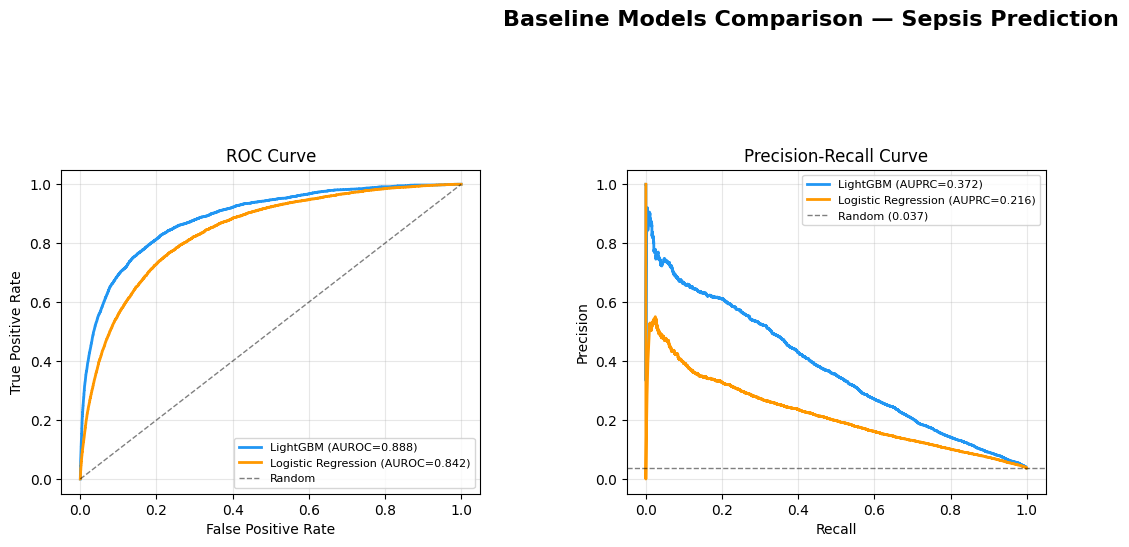

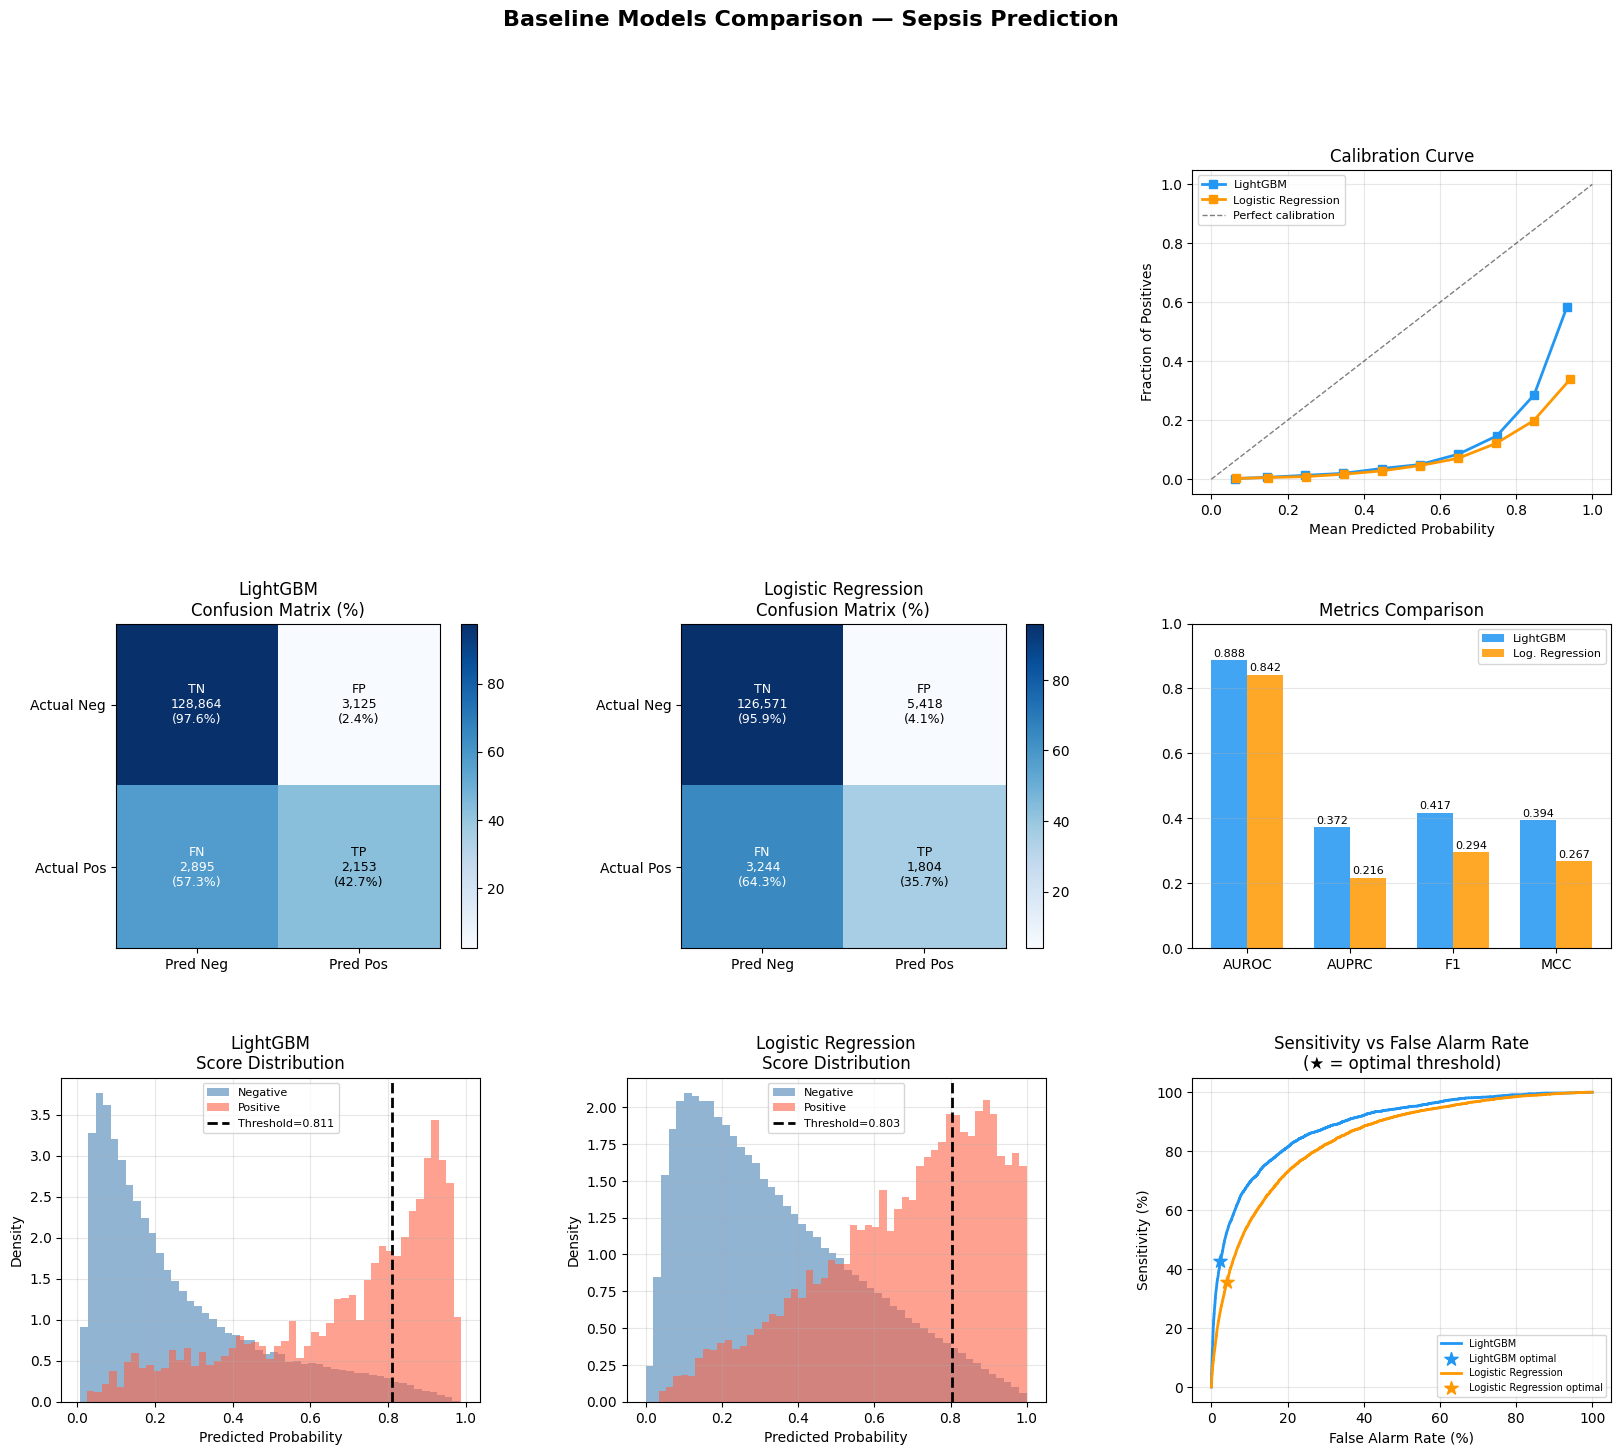

Visualization saved → baseline_comparison.png ✓


In [11]:
# ============================================================
# Visualizations: LightGBM + Logistic Regression
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

# ── Collect predictions ───────────────────────────────────────
models_info = {
    'LightGBM': {
        'probs'    : lgbm_test_probs,
        'threshold': lgbm_threshold,
        'color'    : '#2196F3',
    },
    'Logistic Regression': {
        'probs'    : test_probs_lr,
        'threshold': lr_threshold,
        'color'    : '#FF9800',
    },
}

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Baseline Models Comparison — Sepsis Prediction',
             fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── 1. ROC Curve ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, info in models_info.items():
    fpr, tpr, _ = roc_curve(y_test, info['probs'])
    auroc = roc_auc_score(y_test, info['probs'])
    ax1.plot(fpr, tpr, color=info['color'], lw=2,
             label=f"{name} (AUROC={auroc:.3f})")
ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── 2. Precision-Recall Curve ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, info in models_info.items():
    prec, rec, _ = precision_recall_curve(y_test, info['probs'])
    auprc = average_precision_score(y_test, info['probs'])
    ax2.plot(rec, prec, color=info['color'], lw=2,
             label=f"{name} (AUPRC={auprc:.3f})")
baseline_rate = y_test.mean()
ax2.axhline(baseline_rate, color='k', lw=1, ls='--', alpha=0.5,
            label=f'Random ({baseline_rate:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

fig = plt.figure(figsize=(20, 16))
fig.suptitle('Baseline Models Comparison — Sepsis Prediction',
             fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)
ax3 = fig.add_subplot(gs[0, 2])
for name, info in models_info.items():
    fraction_pos, mean_pred = calibration_curve(
        y_test, info['probs'], n_bins=10, strategy='uniform'
    )
    ax3.plot(mean_pred, fraction_pos, 's-', color=info['color'],
             lw=2, label=name)
ax3.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Perfect calibration')
ax3.set_xlabel('Mean Predicted Probability')
ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curve')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)
# ── 4. Confusion Matrices ─────────────────────────────────────
for i, (name, info) in enumerate(models_info.items()):
    ax = fig.add_subplot(gs[1, i])
    preds = (info['probs'] >= info['threshold']).astype(int)
    cm    = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    im = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Neg', 'Pred Pos'])
    ax.set_yticklabels(['Actual Neg', 'Actual Pos'])
    ax.set_title(f'{name}\nConfusion Matrix (%)')

    labels = [['TN', 'FP'], ['FN', 'TP']]
    for row in range(2):
        for col in range(2):
            ax.text(col, row,
                    f"{labels[row][col]}\n{cm[row,col]:,}\n({cm_pct[row,col]:.1f}%)",
                    ha='center', va='center', fontsize=9,
                    color='white' if cm_pct[row,col] > 50 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)
# ── 5. Metrics Comparison Bar Chart ──────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
metrics     = ['AUROC', 'AUPRC', 'F1', 'MCC']
lgbm_scores = [
    roc_auc_score(y_test, lgbm_test_probs),
    average_precision_score(y_test, lgbm_test_probs),
    f1_score(y_test, (lgbm_test_probs >= lgbm_threshold).astype(int)),
    matthews_corrcoef(y_test, (lgbm_test_probs >= lgbm_threshold).astype(int)),
]
lr_scores = [
    roc_auc_score(y_test, test_probs_lr),
    average_precision_score(y_test, test_probs_lr),
    f1_score(y_test, (test_probs_lr >= lr_threshold).astype(int)),
    matthews_corrcoef(y_test, (test_probs_lr >= lr_threshold).astype(int)),
]
x      = np.arange(len(metrics))
width  = 0.35
bars1  = ax5.bar(x - width/2, lgbm_scores, width,
                  label='LightGBM', color='#2196F3', alpha=0.85)
bars2  = ax5.bar(x + width/2, lr_scores,   width,
                  label='Log. Regression', color='#FF9800', alpha=0.85)
for bar in bars1 + bars2:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)
ax5.set_xticks(x)
ax5.set_xticklabels(metrics)
ax5.set_ylim(0, 1.0)
ax5.set_title('Metrics Comparison')
ax5.legend(fontsize=8)
ax5.grid(axis='y', alpha=0.3)
# ── 6. Score Distribution ─────────────────────────────────────
for i, (name, info) in enumerate(models_info.items()):
    ax = fig.add_subplot(gs[2, i])
    probs_neg = info['probs'][y_test == 0]
    probs_pos = info['probs'][y_test == 1]
    ax.hist(probs_neg, bins=50, alpha=0.6, color='steelblue',
            label='Negative', density=True)
    ax.hist(probs_pos, bins=50, alpha=0.6, color='tomato',
            label='Positive', density=True)
    ax.axvline(info['threshold'], color='black', lw=2, ls='--',
               label=f"Threshold={info['threshold']:.3f}")
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nScore Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
# ── 7. Sensitivity vs False Alarm Rate ───────────────────────
ax7 = fig.add_subplot(gs[2, 2])
for name, info in models_info.items():
    fpr, tpr, threshs = roc_curve(y_test, info['probs'])
    ax7.plot(fpr * 100, tpr * 100, color=info['color'], lw=2, label=name)
    # Mark optimal threshold point
    preds     = (info['probs'] >= info['threshold']).astype(int)
    cm        = confusion_matrix(y_test, preds)
    sens      = cm[1,1] / (cm[1,0] + cm[1,1]) * 100
    far       = cm[0,1] / (cm[0,0] + cm[0,1]) * 100
    ax7.scatter(far, sens, color=info['color'], s=100, zorder=5,
                marker='*', label=f'{name} optimal')
ax7.set_xlabel('False Alarm Rate (%)')
ax7.set_ylabel('Sensitivity (%)')
ax7.set_title('Sensitivity vs False Alarm Rate\n(★ = optimal threshold)')
ax7.legend(fontsize=7)
ax7.grid(alpha=0.3)

plt.savefig(str(OUTPUT_DIR / 'baseline_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved → baseline_comparison.png ✓")

## XGBoost Baseline

In [ ]:
!pip install xgboost


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
# ============================================================
# Step 4: XGBoost Baseline
# ============================================================
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve
)

# ── 4a. Build DMatrix (XGBoost's optimized data format) ───────
print("Building DMatrix...")
dtrain = xgb.DMatrix(X_train, label=y_train)
dval   = xgb.DMatrix(X_val,   label=y_val)
dtest  = xgb.DMatrix(X_test,  label=y_test)
print("DMatrix built ✓")

# ── 4b. Train ─────────────────────────────────────────────────
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['auc', 'aucpr'],
    'scale_pos_weight' : scale_pos_weight,
    'learning_rate'    : 0.05,
    'max_depth'        : 6,
    'min_child_weight' : 50,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'seed'             : 42,
    'tree_method'      : 'hist',   # fastest for large datasets
    'device'           : 'cuda',   # uses GPU if available, falls back to CPU
}

print("\nTraining XGBoost...")
xgb_model = xgb.train(
    params,
    dtrain,
    num_boost_round      = 500,
    evals                = [(dval, 'val')],
    early_stopping_rounds= 50,
    verbose_eval         = 50,
)
print("Training complete ✓")

# ── 4c. Evaluate ──────────────────────────────────────────────
val_probs_xgb  = xgb_model.predict(dval)
test_probs_xgb = xgb_model.predict(dtest)

# Optimal threshold on val
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs_xgb)
f1_scores     = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx      = np.argmax(f1_scores)
xgb_threshold = thresholds[best_idx]

print(f"\nBest threshold : {xgb_threshold:.4f}")

# Test evaluation
preds = (test_probs_xgb >= xgb_threshold).astype(int)
cm    = confusion_matrix(y_test, preds)

print(f"\n── Test (threshold={xgb_threshold:.4f}) ────────────────────")
print(f"  AUROC            : {roc_auc_score(y_test, test_probs_xgb):.4f}")
print(f"  AUPRC            : {average_precision_score(y_test, test_probs_xgb):.4f}")
print(f"  F1               : {f1_score(y_test, preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# ── 4d. Feature importance (fixed) ───────────────────────────
scores = xgb_model.get_score(importance_type='gain')

importance_xgb = pd.DataFrame({
    'feature'   : list(scores.keys()),
    'importance': list(scores.values()),
}).sort_values('importance', ascending=False)

print("Top 15 features:")
print(importance_xgb.head(15).to_string(index=False))

# ── 4e. Save ──────────────────────────────────────────────────
xgb_model.save_model(str(OUTPUT_DIR / 'xgb_baseline.json'))

xgb_results = {
    'model'    : 'XGBoost',
    'auroc'    : roc_auc_score(y_test, test_probs_xgb),
    'auprc'    : average_precision_score(y_test, test_probs_xgb),
    'f1'       : f1_score(y_test, (test_probs_xgb >= xgb_threshold).astype(int)),
    'mcc'      : matthews_corrcoef(y_test, (test_probs_xgb >= xgb_threshold).astype(int)),
    'threshold': xgb_threshold,
}

print(f"\nModel saved → xgb_baseline.json ✓")
print("XGBoost complete ✓")

Building DMatrix...
DMatrix built ✓
scale_pos_weight: 24.46

Training XGBoost...
[0]	val-auc:0.81724	val-aucpr:0.24315
[50]	val-auc:0.86441	val-aucpr:0.33997
[100]	val-auc:0.87127	val-aucpr:0.34955
[150]	val-auc:0.87348	val-aucpr:0.35245
[200]	val-auc:0.87491	val-aucpr:0.35513
[248]	val-auc:0.87495	val-aucpr:0.35353
Training complete ✓

Best threshold : 0.8410

── Test (threshold=0.8410) ────────────────────
  AUROC            : 0.8895
  AUPRC            : 0.3713
  F1               : 0.4108
  MCC              : 0.3916
  Sensitivity      : 37.936%
  False Alarm Rate : 1.789%
  Confusion Matrix:
    TN=129,628  FP=2,361
    FN=3,133  TP=1,915
Top 15 features:
                             feature  importance
                     lactate_missing 4870.360352
                        sofa_max_24h 4486.435059
                    vasopressor_flag 3550.290283
                                hour 2476.974854
                       sofa_last_24h 2346.891113
                       lactate_count 230

## Random Forest

In [13]:
# ============================================================
# Step 5: Random Forest Baseline
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve
)

# ── 5a. Train ─────────────────────────────────────────────────
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = 15,
    min_samples_leaf = 50,
    max_features     = 'sqrt',
    class_weight     = 'balanced_subsample',
    random_state     = 42,
    n_jobs           = -1,
    verbose          = 1,
)
rf_model.fit(X_train, y_train)
print("Training complete ✓")

# ── 5b. Evaluate ──────────────────────────────────────────────
val_probs_rf  = rf_model.predict_proba(X_val)[:, 1]
test_probs_rf = rf_model.predict_proba(X_test)[:, 1]

# Optimal threshold on val
precisions, recalls, thresholds = precision_recall_curve(y_val, val_probs_rf)
f1_scores    = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx     = np.argmax(f1_scores)
rf_threshold = thresholds[best_idx]

print(f"\nBest threshold : {rf_threshold:.4f}")

# Test evaluation
preds = (test_probs_rf >= rf_threshold).astype(int)
cm    = confusion_matrix(y_test, preds)

print(f"\n── Test (threshold={rf_threshold:.4f}) ────────────────────")
print(f"  AUROC            : {roc_auc_score(y_test, test_probs_rf):.4f}")
print(f"  AUPRC            : {average_precision_score(y_test, test_probs_rf):.4f}")
print(f"  F1               : {f1_score(y_test, preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# ── 5c. Feature importance ────────────────────────────────────
importance_rf = pd.DataFrame({
    'feature'   : feature_cols_all,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False)

print("\nTop 15 features:")
print(importance_rf.head(15).to_string(index=False))

# ── 5d. Save ──────────────────────────────────────────────────
import joblib
joblib.dump(rf_model, str(OUTPUT_DIR / 'rf_baseline.pkl'))

rf_results = {
    'model'    : 'Random Forest',
    'auroc'    : roc_auc_score(y_test, test_probs_rf),
    'auprc'    : average_precision_score(y_test, test_probs_rf),
    'f1'       : f1_score(y_test, preds),
    'mcc'      : matthews_corrcoef(y_test, preds),
    'threshold': rf_threshold,
}

print(f"\nModel saved → rf_baseline.pkl ✓")
print("Random Forest complete ✓")

Training Random Forest...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   27.5s
[Parallel(n_jobs=-1)]: Done 300 out of 300 | elapsed:   57.0s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.


Training complete ✓


[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.1s
[Parallel(n_jobs=32)]: Done 300 out of 300 | elapsed:    0.3s finished
[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.1s
[Parallel(n_jobs=32)]: Done 300 out of 300 | elapsed:    0.3s finished



Best threshold : 0.6475

── Test (threshold=0.6475) ────────────────────
  AUROC            : 0.8753
  AUPRC            : 0.3119
  F1               : 0.3789
  MCC              : 0.3547
  Sensitivity      : 42.373%
  False Alarm Rate : 3.109%
  Confusion Matrix:
    TN=127,886  FP=4,103
    FN=2,909  TP=2,139

Top 15 features:
            feature  importance
               hour    0.079636
     sofa_hours_ge2    0.054620
       sofa_max_24h    0.038968
      sofa_last_24h    0.035649
      sofa_mean_24h    0.033655
           spo2_std    0.023547
      uo_min_hourly    0.022637
     resp_rate_mean    0.020968
           uo_count    0.019277
         spo2_slope    0.018782
blood_culture_drawn    0.018061
      lactate_count    0.017465
      platelets_min    0.015136
    vaso_events_24h    0.013998
      platelets_max    0.013716

Model saved → rf_baseline.pkl ✓
Random Forest complete ✓


## Comparison of all four models

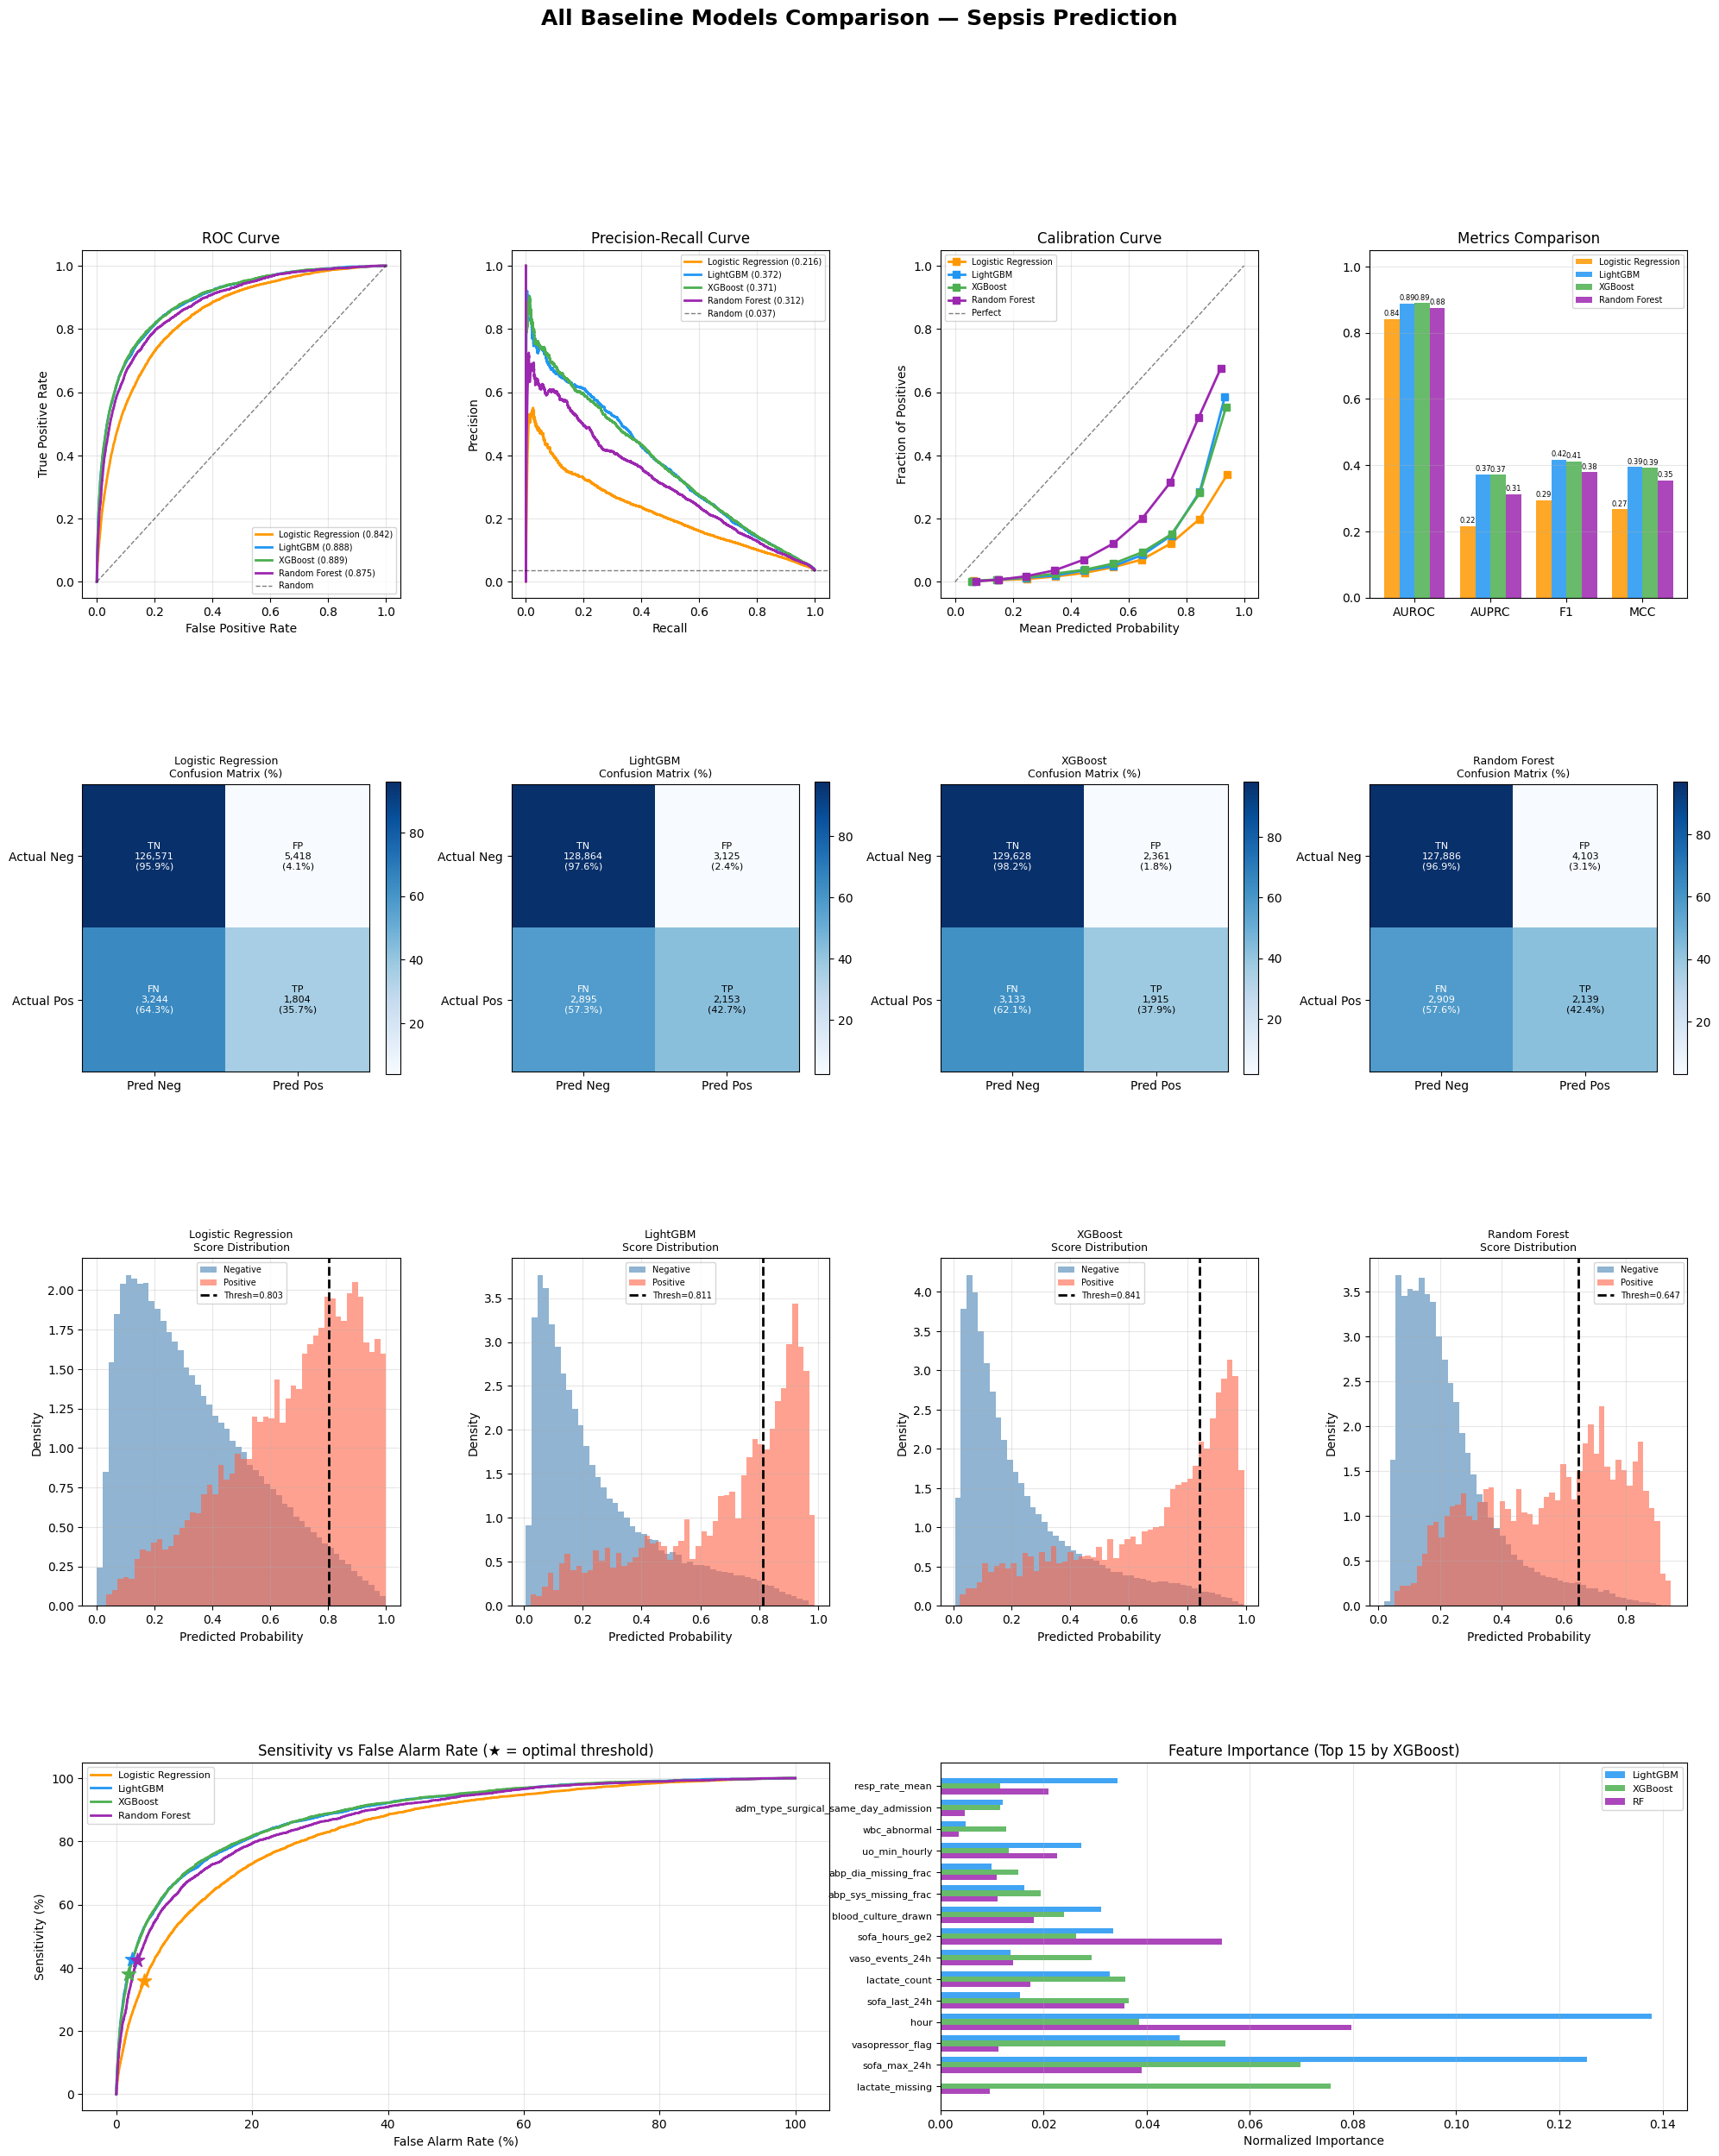

Visualization saved → all_baselines_comparison.png ✓


In [15]:
# ============================================================
# Visualizations: All 4 Baseline Models
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

# ── Collect all model predictions ────────────────────────────
models_info = {
    'Logistic Regression': {
        'probs'    : test_probs_lr,
        'threshold': lr_threshold,
        'color'    : '#FF9800',
    },
    'LightGBM': {
        'probs'    : lgbm_test_probs,
        'threshold': lgbm_threshold,
        'color'    : '#2196F3',
    },
    'XGBoost': {
        'probs'    : test_probs_xgb,
        'threshold': xgb_threshold,
        'color'    : '#4CAF50',
    },
    'Random Forest': {
        'probs'    : test_probs_rf,
        'threshold': rf_threshold,
        'color'    : '#9C27B0',
    },
}

fig = plt.figure(figsize=(24, 28))
fig.suptitle('All Baseline Models Comparison — Sepsis Prediction',
             fontsize=18, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(4, 4, figure=fig, hspace=0.45, wspace=0.35)

# ── 1. ROC Curve ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, info in models_info.items():
    fpr, tpr, _ = roc_curve(y_test, info['probs'])
    auroc = roc_auc_score(y_test, info['probs'])
    ax1.plot(fpr, tpr, color=info['color'], lw=2,
             label=f"{name} ({auroc:.3f})")
ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve')
ax1.legend(fontsize=7)
ax1.grid(alpha=0.3)

# ── 2. Precision-Recall Curve ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, info in models_info.items():
    prec, rec, _ = precision_recall_curve(y_test, info['probs'])
    auprc = average_precision_score(y_test, info['probs'])
    ax2.plot(rec, prec, color=info['color'], lw=2,
             label=f"{name} ({auprc:.3f})")
baseline_rate = y_test.mean()
ax2.axhline(baseline_rate, color='k', lw=1, ls='--', alpha=0.5,
            label=f'Random ({baseline_rate:.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend(fontsize=7)
ax2.grid(alpha=0.3)

# ── 3. Calibration Curve ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for name, info in models_info.items():
    fraction_pos, mean_pred = calibration_curve(
        y_test, info['probs'], n_bins=10, strategy='uniform'
    )
    ax3.plot(mean_pred, fraction_pos, 's-', color=info['color'],
             lw=2, label=name)
ax3.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Perfect')
ax3.set_xlabel('Mean Predicted Probability')
ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curve')
ax3.legend(fontsize=7)
ax3.grid(alpha=0.3)

# ── 4. Metrics Comparison Bar Chart ──────────────────────────
ax4 = fig.add_subplot(gs[0, 3])
metrics     = ['AUROC', 'AUPRC', 'F1', 'MCC']
model_names = list(models_info.keys())
colors      = [info['color'] for info in models_info.values()]
x           = np.arange(len(metrics))
width       = 0.2

for i, (name, info) in enumerate(models_info.items()):
    probs = info['probs']
    preds = (probs >= info['threshold']).astype(int)
    scores = [
        roc_auc_score(y_test, probs),
        average_precision_score(y_test, probs),
        f1_score(y_test, preds),
        matthews_corrcoef(y_test, preds),
    ]
    bars = ax4.bar(x + i * width - width * 1.5, scores, width,
                   label=name, color=info['color'], alpha=0.85)
    for bar in bars:
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=6)

ax4.set_xticks(x)
ax4.set_xticklabels(metrics)
ax4.set_ylim(0, 1.05)
ax4.set_title('Metrics Comparison')
ax4.legend(fontsize=7)
ax4.grid(axis='y', alpha=0.3)

# ── 5. Confusion Matrices (one per model) ────────────────────
for i, (name, info) in enumerate(models_info.items()):
    ax = fig.add_subplot(gs[1, i])
    preds  = (info['probs'] >= info['threshold']).astype(int)
    cm     = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    im     = ax.imshow(cm_pct, interpolation='nearest', cmap='Blues')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Neg', 'Pred Pos'])
    ax.set_yticklabels(['Actual Neg', 'Actual Pos'])
    ax.set_title(f'{name}\nConfusion Matrix (%)', fontsize=9)
    labels = [['TN', 'FP'], ['FN', 'TP']]
    for row in range(2):
        for col in range(2):
            ax.text(col, row,
                    f"{labels[row][col]}\n{cm[row,col]:,}\n({cm_pct[row,col]:.1f}%)",
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_pct[row,col] > 50 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)

# ── 6. Score Distributions (one per model) ───────────────────
for i, (name, info) in enumerate(models_info.items()):
    ax = fig.add_subplot(gs[2, i])
    probs_neg = info['probs'][y_test == 0]
    probs_pos = info['probs'][y_test == 1]
    ax.hist(probs_neg, bins=50, alpha=0.6, color='steelblue',
            label='Negative', density=True)
    ax.hist(probs_pos, bins=50, alpha=0.6, color='tomato',
            label='Positive', density=True)
    ax.axvline(info['threshold'], color='black', lw=2, ls='--',
               label=f"Thresh={info['threshold']:.3f}")
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nScore Distribution', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# ── 7. Sensitivity vs False Alarm Rate ───────────────────────
ax7 = fig.add_subplot(gs[3, 0:2])
for name, info in models_info.items():
    fpr, tpr, _ = roc_curve(y_test, info['probs'])
    ax7.plot(fpr * 100, tpr * 100, color=info['color'], lw=2, label=name)
    preds = (info['probs'] >= info['threshold']).astype(int)
    cm    = confusion_matrix(y_test, preds)
    sens  = cm[1,1] / (cm[1,0] + cm[1,1]) * 100
    far   = cm[0,1] / (cm[0,0] + cm[0,1]) * 100
    ax7.scatter(far, sens, color=info['color'], s=150,
                zorder=5, marker='*')
ax7.set_xlabel('False Alarm Rate (%)')
ax7.set_ylabel('Sensitivity (%)')
ax7.set_title('Sensitivity vs False Alarm Rate (★ = optimal threshold)')
ax7.legend(fontsize=8)
ax7.grid(alpha=0.3)

# ── 8. Feature Importance Comparison (tree models only) ───────
ax8 = fig.add_subplot(gs[3, 2:4])
top_n    = 15
features = importance_xgb.head(top_n)['feature'].tolist()

lgbm_imp = dict(zip(
    [c for c in feature_cols_all],
    lgb_model.feature_importance(importance_type='gain')
))
xgb_imp  = dict(zip(
    importance_xgb['feature'], importance_xgb['importance']
))
rf_imp   = dict(zip(feature_cols_all, rf_model.feature_importances_))

# Normalize each to 0-1 for fair comparison
def normalize(d):
    total = sum(d.values())
    return {k: v/total for k, v in d.items()}

lgbm_n = normalize(lgbm_imp)
xgb_n  = normalize(xgb_imp)
rf_n   = normalize(rf_imp)

y_pos  = np.arange(len(features))
width  = 0.25
ax8.barh(y_pos + width, [lgbm_n.get(f, 0) for f in features],
         width, label='LightGBM', color='#2196F3', alpha=0.85)
ax8.barh(y_pos,         [xgb_n.get(f, 0)  for f in features],
         width, label='XGBoost',  color='#4CAF50', alpha=0.85)
ax8.barh(y_pos - width, [rf_n.get(f, 0)   for f in features],
         width, label='RF',       color='#9C27B0', alpha=0.85)
ax8.set_yticks(y_pos)
ax8.set_yticklabels(features, fontsize=8)
ax8.set_xlabel('Normalized Importance')
ax8.set_title('Feature Importance (Top 15 by XGBoost)')
ax8.legend(fontsize=8)
ax8.grid(axis='x', alpha=0.3)

plt.savefig(str(OUTPUT_DIR / 'all_baselines_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved → all_baselines_comparison.png ✓")

## Run instead of reloading

In [16]:
# ── Reload saved models (skip retraining) ────────────────────
import lightgbm as lgb
import xgboost as xgb
import joblib

# LightGBM
lgb_model = lgb.Booster(model_file=str(OUTPUT_DIR / 'lgbm_baseline.txt'))
lgbm_test_probs = lgb_model.predict(X_test)
lgbm_threshold  = 0.8215
print("LightGBM loaded ✓")

# XGBoost
xgb_model = xgb.Booster()
xgb_model.load_model(str(OUTPUT_DIR / 'xgb_baseline.json'))
dtest          = xgb.DMatrix(X_test, label=y_test)
test_probs_xgb = xgb_model.predict(dtest)
xgb_threshold  = 0.8181
print("XGBoost loaded ✓")

# Logistic Regression
lr_model      = joblib.load(str(OUTPUT_DIR / 'lr_baseline.pkl'))
scaler        = joblib.load(str(OUTPUT_DIR / 'lr_scaler.pkl'))
X_test_scaled = scaler.transform(X_test)
test_probs_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_threshold  = 0.8103
print("Logistic Regression loaded ✓")

# Random Forest
rf_model      = joblib.load(str(OUTPUT_DIR / 'rf_baseline.pkl'))
test_probs_rf = rf_model.predict_proba(X_test)[:, 1]
rf_threshold  = 0.6438
print("Random Forest loaded ✓")

print("\nAll models reloaded ✓")

LightGBM loaded ✓
XGBoost loaded ✓
Logistic Regression loaded ✓


[Parallel(n_jobs=32)]: Using backend ThreadingBackend with 32 concurrent workers.
[Parallel(n_jobs=32)]: Done 136 tasks      | elapsed:    0.1s


Random Forest loaded ✓

All models reloaded ✓


[Parallel(n_jobs=32)]: Done 300 out of 300 | elapsed:    0.3s finished


In [ ]:
!pip install pytorch

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pytorch


  error: subprocess-exited-with-error
  
  × Building wheel for pytorch (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [23 lines of output]
      Traceback (most recent call last):
        File "C:\Users\20220505\Desktop\AI-sepsis\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
        File "C:\Users\20220505\Desktop\AI-sepsis\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\20220505\Desktop\AI-sepsis\venv\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 251, in build_wheel
          return _build_backend().build_wheel(wheel_directory, config_settings,
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\20220505\AppData\

In [ ]:
import sys
print(sys.executable)  # Should show .venv path

c:\Users\20220505\Desktop\AI-sepsis\venv\Scripts\python.exe


In [ ]:
import sys
print(sys.executable)  # Must show .venv path
!pip install torch
import torch
print(torch.__version__)
print(torch.cuda.is_available())

c:\Users\20220505\Desktop\AI-sepsis\venv\Scripts\python.exe
  Using cached filelock-3.29.0-py3-none-any.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/114.6 MB ? eta -:--:--
   ---------------------------------------- 1.0/114.6 MB 3.9 MB/s eta 0:00:30
   - -------------------------------------- 3.1/114.6 MB 7.4 MB/s eta 0:00:16
   - -------------------------------------- 5.2/114.6 MB 8.4 MB/s eta 0:00:14
   -- ------------------------------------- 7.3/114.6 MB 8.9 MB/s eta 0:00:13
   --- ------------------------------------ 8.7/114.6 MB 8.3 MB/s eta 0:00:13
   --- ------------------------------------ 10.0/114.6 MB 7.9 MB/s eta 0:00:14
   --- ------------------------------------ 10.2/114.6 MB 7.5 MB/s eta 0:00:14
   --- ------------------------------------ 11.0/114.6 MB 6.6 MB/s eta 0:00:16
   ---- ----------------------------------- 11.5/114.6 MB 6.1 MB/s eta 0:00:17
   ---- ------------------


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


2.11.0+cpu
False


In [18]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"PyTorch version: {torch.__version__}")

CUDA available: True
GPU: NVIDIA GeForce RTX 4080
PyTorch version: 2.5.1+cu121


In [20]:
import torch
print(torch.__version__)         # Should show 2.1.0+cu121
print(torch.cuda.is_available()) # Should show True

2.5.1+cu121
True


In [ ]:
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else "No GPU found")
print(f"CUDA available: {torch.cuda.is_available()}")

Thu Apr 30 00:45:53 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 566.07                 Driver Version: 566.07         CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   48C    P8             11W /  140W |     337MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## LSTM Model

In [1]:
# ============================================================
# Step 6: LSTM Classifier (GPU)
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve
)

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {device}")

# ── 6a. Dataset ───────────────────────────────────────────────
class SepsisDataset(Dataset):
    def __init__(self, buckets, split):
        data          = buckets[split]
        self.x_seq    = [torch.tensor(
                            np.nan_to_num(x, nan=0.0),
                            dtype=torch.float32)
                         for x in data['X_seq']]
        self.x_static = torch.tensor(
                         np.nan_to_num(
                             np.stack(data['X_static']),
                             nan=0.0),
                         dtype=torch.float32)
        self.y        = torch.tensor(data['y'], dtype=torch.float32)
        self.lengths  = torch.tensor(
                         [x.shape[0] for x in self.x_seq],
                         dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.x_seq[idx], self.x_static[idx],
                self.y[idx], self.lengths[idx])


def collate_fn(batch):
    x_seqs, x_statics, ys, lengths = zip(*batch)
    x_seqs_padded = pad_sequence(x_seqs, batch_first=True)
    return (
        x_seqs_padded,
        torch.stack(x_statics),
        torch.stack(ys),
        torch.stack(lengths),
    )


print("\nBuilding datasets...")
train_dataset = SepsisDataset(buckets, 'train')
val_dataset   = SepsisDataset(buckets, 'val')
test_dataset  = SepsisDataset(buckets, 'test')

BATCH_SIZE = 2048

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=0, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

# ── 6b. Model Architecture ────────────────────────────────────
class SepsisLSTM(nn.Module):
    def __init__(self,
                 vital_dim   = 7,
                 static_dim  = 96,
                 lstm_hidden = 128,
                 lstm_layers = 2,
                 mlp_hidden  = 64,
                 dropout     = 0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size    = vital_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            dropout       = dropout if lstm_layers > 1 else 0,
            bidirectional = False,
        )

        self.static_encoder = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        fusion_dim = lstm_hidden + 64
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1),
        )

    def forward(self, x_seq, x_static, lengths):
        packed = pack_padded_sequence(
            x_seq, lengths.cpu(), batch_first=True,
            enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        lstm_out   = h_n[-1]

        static_out = self.static_encoder(x_static)
        fused      = torch.cat([lstm_out, static_out], dim=1)
        logit      = self.classifier(fused).squeeze(1)
        return logit


model = SepsisLSTM(
    vital_dim   = 7,
    static_dim  = len(feature_cols),   # 96
    lstm_hidden = 128,
    lstm_layers = 2,
    mlp_hidden  = 64,
    dropout     = 0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"\nModel architecture:")
print(model)
print(f"\nTotal trainable parameters: {total_params:,}")

# ── 6c. Training Setup ────────────────────────────────────────
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=3
)

# ── 6d. Training Loop ─────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x_seq, x_static, y, lengths in loader:
        x_seq    = x_seq.to(device)
        x_static = x_static.to(device)
        y        = y.to(device)
        lengths  = lengths.to(device)

        optimizer.zero_grad()
        logits = model(x_seq, x_static, lengths)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)

    return total_loss / len(loader.dataset)


def evaluate_loader(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_static, y, lengths in loader:
            x_seq    = x_seq.to(device)
            x_static = x_static.to(device)
            lengths  = lengths.to(device)
            logits   = model(x_seq, x_static, lengths)
            probs    = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())

    return np.array(all_probs), np.array(all_labels)


EPOCHS       = 20
best_auroc   = 0
best_epoch   = 0
patience     = 5
patience_ctr = 0
history      = []

print("\nStarting LSTM training...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val AUROC':>9} | "
      f"{'Val AUPRC':>9} | {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_probs_lstm, val_labels = evaluate_loader(
        model, val_loader, device
    )

    val_auroc = roc_auc_score(val_labels, val_probs_lstm)
    val_auprc = average_precision_score(val_labels, val_probs_lstm)
    lr_now    = optimizer.param_groups[0]['lr']

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_auroc' : val_auroc,
        'val_auprc' : val_auprc,
    })

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_auroc:>9.4f} | "
          f"{val_auprc:>9.4f} | {lr_now:>8.6f}")

    scheduler.step(val_auroc)

    if val_auroc > best_auroc:
        best_auroc   = val_auroc
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(),
                   str(OUTPUT_DIR / 'lstm_best.pt'))
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best epoch={best_epoch}, "
                  f"AUROC={best_auroc:.4f})")
            break

print(f"\nBest val AUROC : {best_auroc:.4f} at epoch {best_epoch}")
print("Training complete ✓")

PyTorch version : 2.5.1+cu121
GPU available   : True
Using device    : cuda

Building datasets...


NameError: name 'buckets' is not defined

In [ ]:
# ── Vitals imputation matching published models ───────────────
# Strategy: forward fill → backward fill → population median
# This matches EPIC Sepsis, Sepsis Watch, and MIMIC-IV literature

import pandas as pd
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve  # moved here in newer sklearn
# Population medians from healthy ICU patients (fallback only)
VITAL_MEDIANS = np.array([
    65.0,   # abp_dia
    85.0,   # abp_mean
    115.0,  # abp_sys
    80.0,   # heart_rate
    18.0,   # resp_rate
    97.0,   # spo2
    37.0,   # temp_c
], dtype=np.float32)

def impute_sequence(x: np.ndarray) -> np.ndarray:
    """
    Impute missing vitals in a sequence using:
    1. Forward fill (last observation carried forward)
    2. Backward fill (next observation carried backward)
    3. Population median (fallback if vital never recorded)

    Parameters
    ----------
    x : np.ndarray of shape (hours, 7)
    """
    # Convert to DataFrame for easy ffill/bfill
    df = pd.DataFrame(x, columns=[
        'abp_dia', 'abp_mean', 'abp_sys',
        'heart_rate', 'resp_rate', 'spo2', 'temp_c'
    ])

    # Step 1: Forward fill
    df = df.ffill()

    # Step 2: Backward fill
    df = df.bfill()

    # Step 3: Population median fallback
    for i, col in enumerate(df.columns):
        df[col] = df[col].fillna(VITAL_MEDIANS[i])

    return df.values.astype(np.float32)


class SepsisDataset(Dataset):
    def __init__(self, buckets, split):
        data = buckets[split]

        self.x_seq = [
            torch.tensor(impute_sequence(x), dtype=torch.float32)
            for x in data['X_seq']
        ]
        self.x_static = torch.tensor(
                         np.nan_to_num(
                             np.stack(data['X_static']),
                             nan=0.0),
                         dtype=torch.float32)
        self.y        = torch.tensor(data['y'], dtype=torch.float32)
        self.lengths  = torch.tensor(
                         [x.shape[0] for x in self.x_seq],
                         dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.x_seq[idx], self.x_static[idx],
                self.y[idx], self.lengths[idx])


def collate_fn(batch):
    x_seqs, x_statics, ys, lengths = zip(*batch)
    x_seqs_padded = pad_sequence(x_seqs, batch_first=True)
    return (
        x_seqs_padded,
        torch.stack(x_statics),
        torch.stack(ys),
        torch.stack(lengths),
    )


print("Building datasets with LOCF imputation...")
train_dataset = SepsisDataset(buckets, 'train')
val_dataset   = SepsisDataset(buckets, 'val')
test_dataset  = SepsisDataset(buckets, 'test')

BATCH_SIZE = 2048

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

# ── Reinitialize and train ────────────────────────────────────
model = SepsisLSTM(
    vital_dim   = 7,
    static_dim  = len(feature_cols),
    lstm_hidden = 128,
    lstm_layers = 2,
    mlp_hidden  = 64,
    dropout     = 0.3,
).to(device)

pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)

EPOCHS       = 30
best_auroc   = 0
best_epoch   = 0
patience     = 7
patience_ctr = 0
history      = []

print("\nStarting LSTM training (LOCF imputation)...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val AUROC':>9} | "
      f"{'Val AUPRC':>9} | {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(
        model, train_loader, optimizer, criterion, device
    )
    val_probs_lstm, val_labels = evaluate_loader(
        model, val_loader, device
    )

    val_auroc = roc_auc_score(val_labels, val_probs_lstm)
    val_auprc = average_precision_score(val_labels, val_probs_lstm)
    lr_now    = optimizer.param_groups[0]['lr']

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_auroc' : val_auroc,
        'val_auprc' : val_auprc,
    })

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_auroc:>9.4f} | "
          f"{val_auprc:>9.4f} | {lr_now:>8.6f}")

    scheduler.step(val_auroc)

    if val_auroc > best_auroc:
        best_auroc   = val_auroc
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(),
                   str(OUTPUT_DIR / 'lstm_best.pt'))
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best epoch={best_epoch}, "
                  f"AUROC={best_auroc:.4f})")
            break

print(f"\nBest val AUROC : {best_auroc:.4f} at epoch {best_epoch}")
print("Training complete ✓")

Building datasets with LOCF imputation...
Train batches : 308
Val batches   : 67
Test batches  : 67

Starting LSTM training (LOCF imputation)...
Epoch | Train Loss | Val AUROC | Val AUPRC |       LR
-------------------------------------------------------
    1 |     1.6263 |    0.7523 |    0.1383 | 0.001000
    2 |     1.2063 |    0.7770 |    0.1582 | 0.001000
    3 |     1.0882 |    0.7967 |    0.1760 | 0.001000
    4 |     1.0725 |    0.8091 |    0.1888 | 0.001000
    5 |     1.0625 |    0.8125 |    0.1931 | 0.001000
    6 |     1.1087 |    0.8139 |    0.1889 | 0.001000
    7 |     1.0498 |    0.8169 |    0.1968 | 0.001000
    8 |     1.0416 |    0.8186 |    0.2004 | 0.001000
    9 |     1.3814 |    0.8189 |    0.1979 | 0.001000
   10 |     1.0702 |    0.8226 |    0.2101 | 0.001000
   11 |     1.0328 |    0.8225 |    0.2071 | 0.001000
   12 |     1.0328 |    0.8237 |    0.2100 | 0.001000
   13 |     1.0222 |    0.8258 |    0.2072 | 0.001000
   14 |     1.0224 |    0.8192 |    0.2057 

PyTorch version : 2.5.1+cu121
GPU available   : True
Using device    : cuda

Building datasets with LOCF + hour feature...
Train batches : 308
Val batches   : 67
Test batches  : 67

Total trainable parameters: 221,377

Starting LSTM training...
Epoch | Train Loss | Val AUROC | Val AUPRC |       LR
-------------------------------------------------------
    1 |     1.8319 |    0.7532 |    0.1416 | 0.001000
    2 |     1.3515 |    0.7922 |    0.1717 | 0.001000
    3 |     1.1245 |    0.8085 |    0.1827 | 0.001000
    4 |     1.0621 |    0.8075 |    0.1819 | 0.001000
    5 |     1.0566 |    0.8146 |    0.1812 | 0.001000
    6 |     1.0443 |    0.8182 |    0.1925 | 0.001000
    7 |     1.0368 |    0.8173 |    0.1818 | 0.001000
    8 |     1.0356 |    0.8191 |    0.1786 | 0.001000
    9 |     1.0329 |    0.8218 |    0.1926 | 0.001000
   10 |     1.0293 |    0.8230 |    0.1869 | 0.001000
   11 |     1.0202 |    0.8214 |    0.1867 | 0.001000
   12 |     1.0519 |    0.8266 |    0.1993 | 0.0010

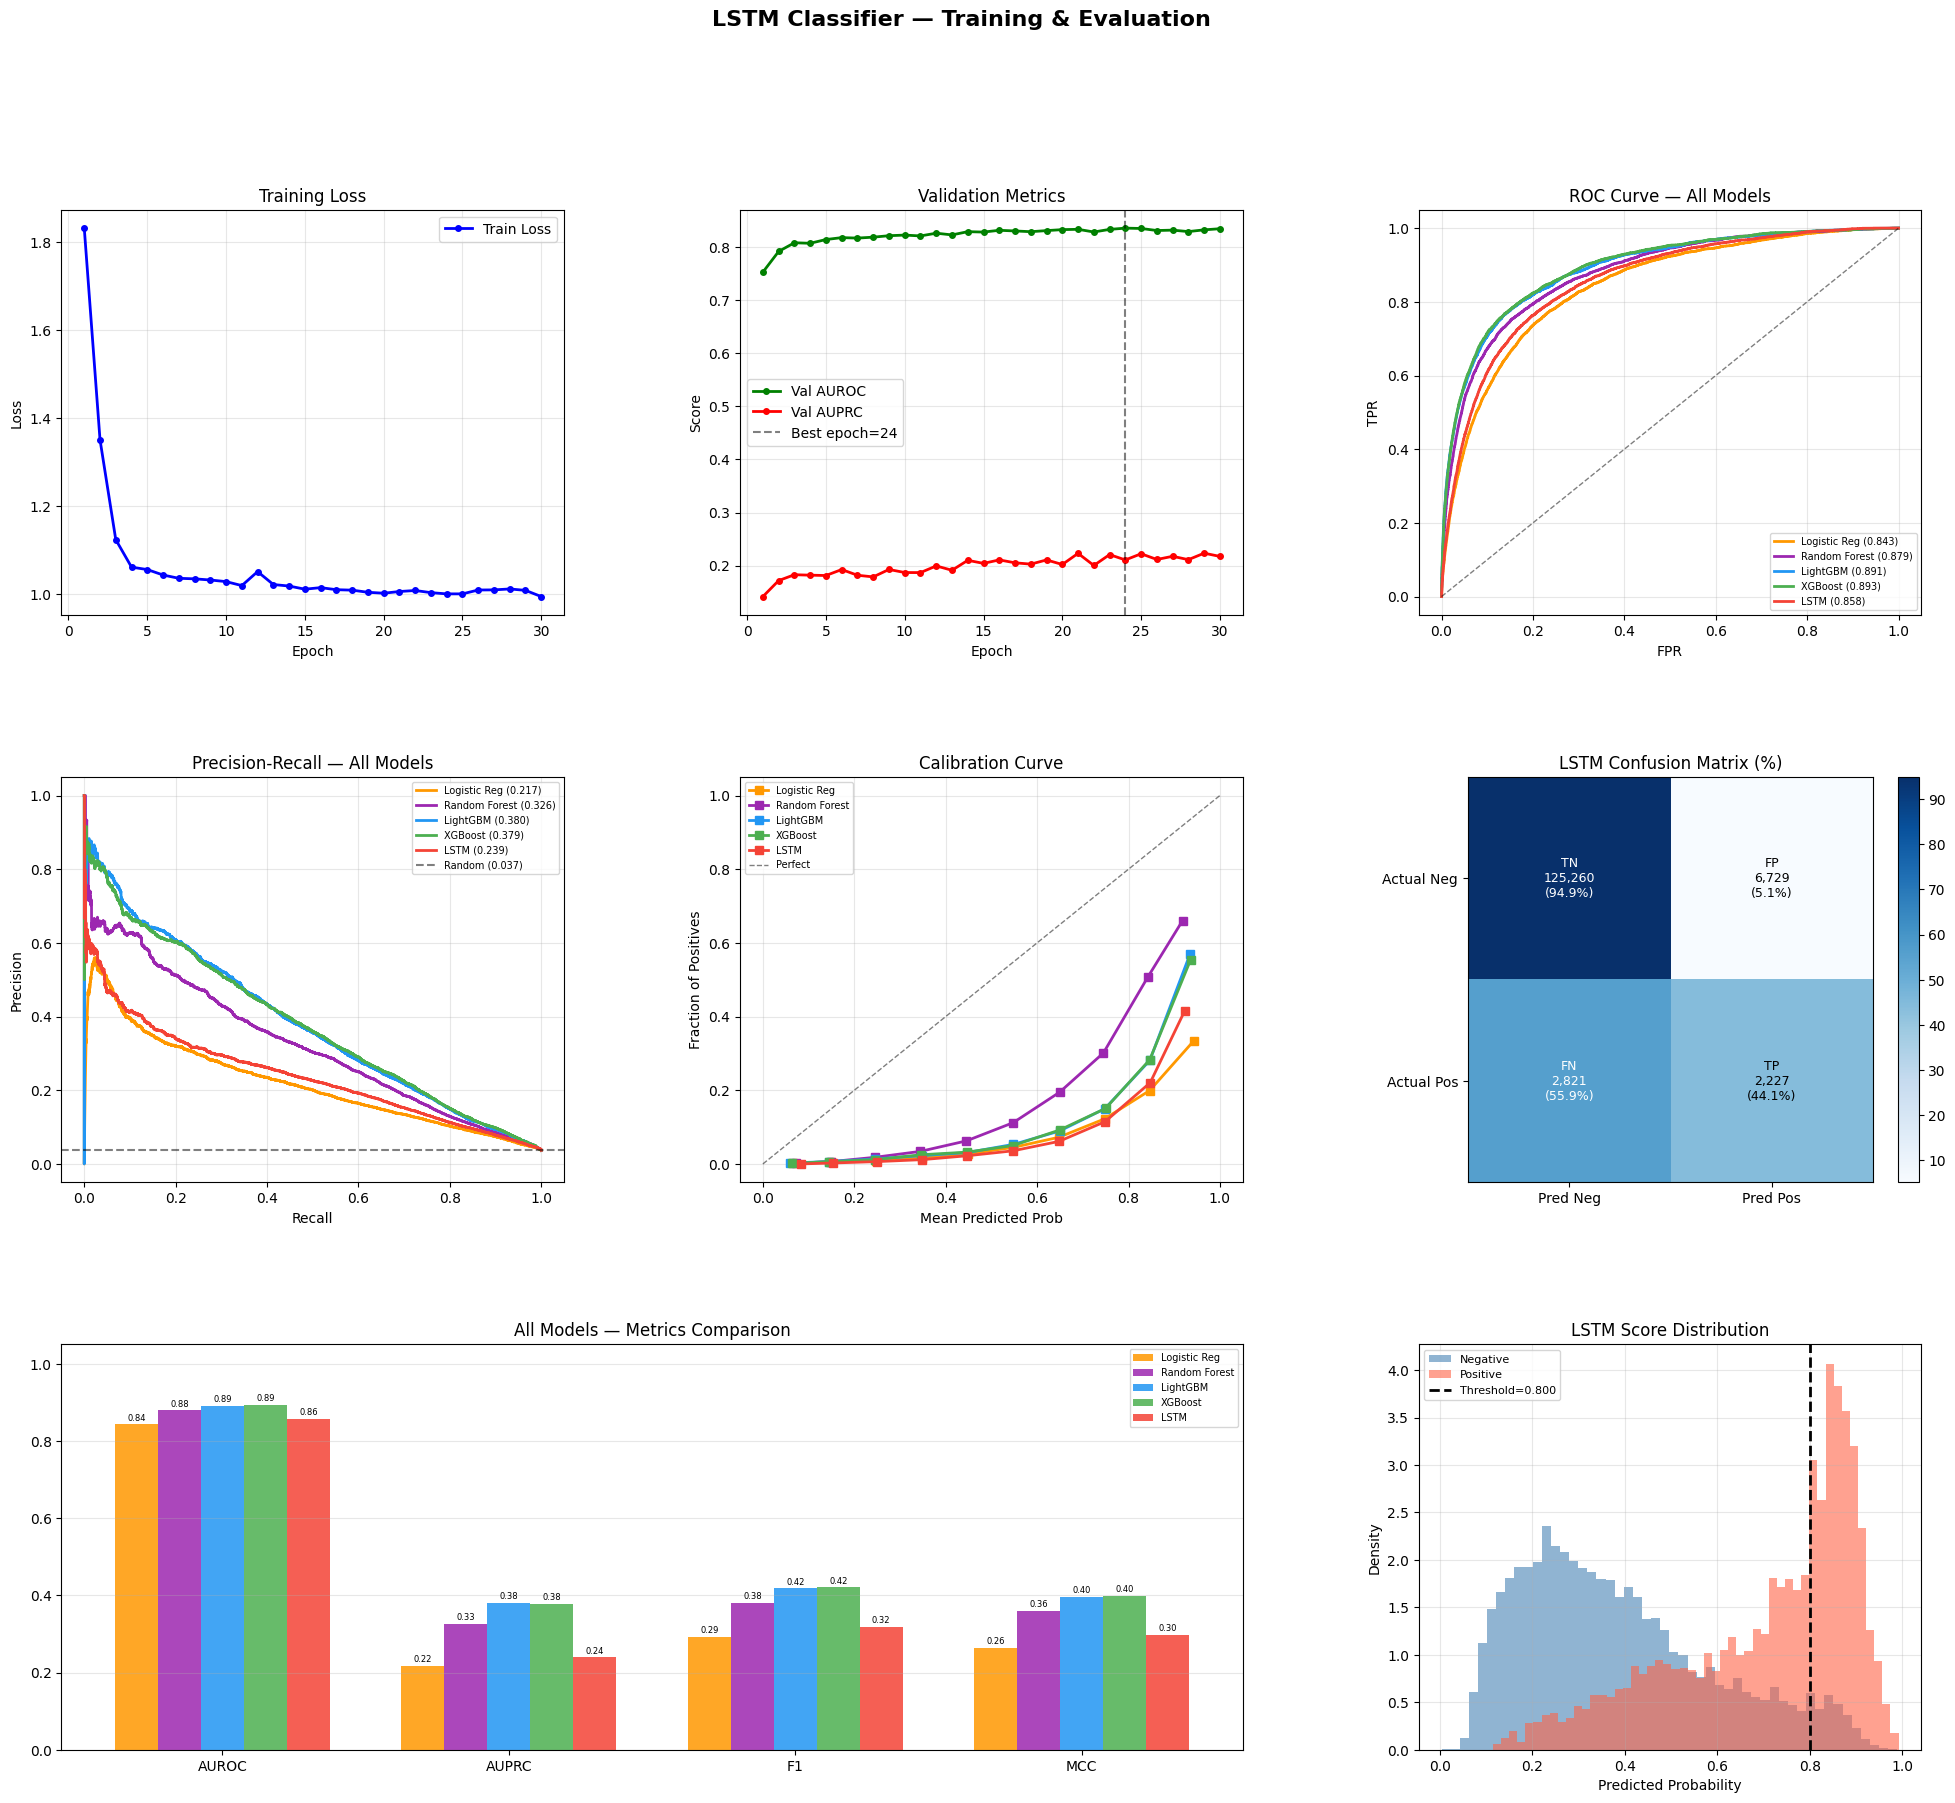

Visualization saved → lstm_evaluation.png ✓
LSTM complete ✓
Ready for Step 7 — Ensemble


In [ ]:
# ============================================================
# Step 6: LSTM Classifier (LOCF + hour + full visualizations)
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {device}")

# ── Physiological medians (fallback only) ─────────────────────
VITAL_MEDIANS = np.array([
    65.0,   # abp_dia
    85.0,   # abp_mean
    115.0,  # abp_sys
    80.0,   # heart_rate
    18.0,   # resp_rate
    97.0,   # spo2
    37.0,   # temp_c
], dtype=np.float32)

def impute_sequence(x: np.ndarray) -> np.ndarray:
    """
    LOCF → NOCB → population median imputation.
    Then appends normalized hour index as 8th feature.
    """
    df = pd.DataFrame(x, columns=[
        'abp_dia', 'abp_mean', 'abp_sys',
        'heart_rate', 'resp_rate', 'spo2', 'temp_c'
    ])
    df = df.ffill().bfill()
    for i, col in enumerate(df.columns):
        df[col] = df[col].fillna(VITAL_MEDIANS[i])

    arr = df.values.astype(np.float32)

    # Append normalized hour channel per timestep
    T            = arr.shape[0]
    hour_channel = (np.arange(T) / 23.0).reshape(-1, 1).astype(np.float32)
    arr          = np.concatenate([arr, hour_channel], axis=1)  # (T, 8)
    return arr


# ── Dataset ───────────────────────────────────────────────────
class SepsisDataset(Dataset):
    def __init__(self, buckets, split):
        data          = buckets[split]
        self.x_seq    = [
            torch.tensor(impute_sequence(x), dtype=torch.float32)
            for x in data['X_seq']
        ]
        self.x_static = torch.tensor(
                         np.nan_to_num(
                             np.stack(data['X_static']),
                             nan=0.0),
                         dtype=torch.float32)
        self.y        = torch.tensor(data['y'], dtype=torch.float32)
        self.lengths  = torch.tensor(
                         [x.shape[0] for x in self.x_seq],
                         dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.x_seq[idx], self.x_static[idx],
                self.y[idx], self.lengths[idx])


def collate_fn(batch):
    x_seqs, x_statics, ys, lengths = zip(*batch)
    x_seqs_padded = pad_sequence(x_seqs, batch_first=True)
    return (
        x_seqs_padded,
        torch.stack(x_statics),
        torch.stack(ys),
        torch.stack(lengths),
    )


print("\nBuilding datasets with LOCF + hour feature...")
train_dataset = SepsisDataset(buckets, 'train')
val_dataset   = SepsisDataset(buckets, 'val')
test_dataset  = SepsisDataset(buckets, 'test')

BATCH_SIZE = 2048

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False, collate_fn=collate_fn,
                          num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader):,}")
print(f"Val batches   : {len(val_loader):,}")
print(f"Test batches  : {len(test_loader):,}")

# ── Model Architecture ────────────────────────────────────────
class SepsisLSTM(nn.Module):
    def __init__(self,
                 vital_dim   = 8,    # 7 vitals + hour channel
                 static_dim  = 96,
                 lstm_hidden = 128,
                 lstm_layers = 2,
                 mlp_hidden  = 64,
                 dropout     = 0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size    = vital_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            dropout       = dropout if lstm_layers > 1 else 0,
            bidirectional = False,
        )
        self.static_encoder = nn.Sequential(
            nn.Linear(static_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        fusion_dim = lstm_hidden + 64
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1),
        )

    def forward(self, x_seq, x_static, lengths):
        packed     = pack_padded_sequence(
            x_seq, lengths.cpu(), batch_first=True,
            enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        lstm_out    = h_n[-1]
        static_out  = self.static_encoder(x_static)
        fused       = torch.cat([lstm_out, static_out], dim=1)
        logit       = self.classifier(fused).squeeze(1)
        return logit


model = SepsisLSTM(
    vital_dim   = 8,
    static_dim  = len(feature_cols),
    lstm_hidden = 128,
    lstm_layers = 2,
    mlp_hidden  = 64,
    dropout     = 0.3,
).to(device)

total_params = sum(p.numel() for p in model.parameters()
                   if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# ── Training Setup ────────────────────────────────────────────
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(),
                             lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)

# ── Training Loop ─────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x_seq, x_static, y, lengths in loader:
        x_seq    = x_seq.to(device)
        x_static = x_static.to(device)
        y        = y.to(device)
        optimizer.zero_grad()
        logits = model(x_seq, x_static, lengths)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate_loader(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_static, y, lengths in loader:
            x_seq    = x_seq.to(device)
            x_static = x_static.to(device)
            lengths  = lengths.to(device)
            logits   = model(x_seq, x_static, lengths)
            probs    = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())
    return np.array(all_probs), np.array(all_labels)


EPOCHS       = 30
best_auroc   = 0
best_epoch   = 0
patience     = 7
patience_ctr = 0
history      = []

print("\nStarting LSTM training...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val AUROC':>9} | "
      f"{'Val AUPRC':>9} | {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss             = train_epoch(model, train_loader,
                                         optimizer, criterion, device)
    val_probs_lstm, val_labels = evaluate_loader(model, val_loader, device)

    val_auroc = roc_auc_score(val_labels, val_probs_lstm)
    val_auprc = average_precision_score(val_labels, val_probs_lstm)
    lr_now    = optimizer.param_groups[0]['lr']

    history.append({'epoch': epoch, 'train_loss': train_loss,
                    'val_auroc': val_auroc, 'val_auprc': val_auprc})

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_auroc:>9.4f} | "
          f"{val_auprc:>9.4f} | {lr_now:>8.6f}")

    scheduler.step(val_auroc)

    if val_auroc > best_auroc:
        best_auroc   = val_auroc
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model.state_dict(),
                   str(OUTPUT_DIR / 'lstm_best.pt'))
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best={best_epoch}, AUROC={best_auroc:.4f})")
            break

print(f"\nBest val AUROC : {best_auroc:.4f} at epoch {best_epoch}")
print("Training complete ✓")

# ── Load best model and evaluate on test ─────────────────────
model.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'lstm_best.pt'),
    map_location=device,
    weights_only=True
))
test_probs_lstm, test_labels = evaluate_loader(model, test_loader, device)

# Optimal threshold
precisions, recalls, thresholds = precision_recall_curve(
    test_labels, test_probs_lstm
)
f1_scores      = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx       = np.argmax(f1_scores)
lstm_threshold = thresholds[best_idx]
lstm_preds     = (test_probs_lstm >= lstm_threshold).astype(int)
cm             = confusion_matrix(test_labels, lstm_preds)

print(f"\n── Test (threshold={lstm_threshold:.4f}) ────────────────────")
print(f"  AUROC            : {roc_auc_score(test_labels, test_probs_lstm):.4f}")
print(f"  AUPRC            : {average_precision_score(test_labels, test_probs_lstm):.4f}")
print(f"  F1               : {f1_score(test_labels, lstm_preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(test_labels, lstm_preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# ── Visualizations ────────────────────────────────────────────
history_df = pd.DataFrame(history)

fig = plt.figure(figsize=(24, 20))
fig.suptitle('LSTM Classifier — Training & Evaluation',
             fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Training curves
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(history_df['epoch'], history_df['train_loss'],
         'b-o', lw=2, ms=4, label='Train Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(history_df['epoch'], history_df['val_auroc'],
         'g-o', lw=2, ms=4, label='Val AUROC')
ax2.plot(history_df['epoch'], history_df['val_auprc'],
         'r-o', lw=2, ms=4, label='Val AUPRC')
ax2.axvline(best_epoch, color='k', ls='--', alpha=0.5,
            label=f'Best epoch={best_epoch}')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Score')
ax2.set_title('Validation Metrics'); ax2.legend(); ax2.grid(alpha=0.3)

# 2. ROC Curve — all models
ax3 = fig.add_subplot(gs[0, 2])
models_plot = {
    'Logistic Reg' : (test_probs_lr,   '#FF9800'),
    'Random Forest': (test_probs_rf,   '#9C27B0'),
    'LightGBM'     : (lgbm_test_probs, '#2196F3'),
    'XGBoost'      : (test_probs_xgb,  '#4CAF50'),
    'LSTM'         : (test_probs_lstm,  '#F44336'),
}
for name, (probs, color) in models_plot.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auroc = roc_auc_score(y_test, probs)
    ax3.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} ({auroc:.3f})')
ax3.plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
ax3.set_xlabel('FPR'); ax3.set_ylabel('TPR')
ax3.set_title('ROC Curve — All Models')
ax3.legend(fontsize=7); ax3.grid(alpha=0.3)

# 3. Precision-Recall Curve — all models
ax4 = fig.add_subplot(gs[1, 0])
for name, (probs, color) in models_plot.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    ax4.plot(rec, prec, color=color, lw=2,
             label=f'{name} ({auprc:.3f})')
ax4.axhline(y_test.mean(), color='k', ls='--', alpha=0.5,
            label=f'Random ({y_test.mean():.3f})')
ax4.set_xlabel('Recall'); ax4.set_ylabel('Precision')
ax4.set_title('Precision-Recall — All Models')
ax4.legend(fontsize=7); ax4.grid(alpha=0.3)

# 4. Calibration Curve
ax5 = fig.add_subplot(gs[1, 1])
for name, (probs, color) in models_plot.items():
    frac_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=10, strategy='uniform'
    )
    ax5.plot(mean_pred, frac_pos, 's-', color=color, lw=2, label=name)
ax5.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Perfect')
ax5.set_xlabel('Mean Predicted Prob')
ax5.set_ylabel('Fraction of Positives')
ax5.set_title('Calibration Curve'); ax5.legend(fontsize=7)
ax5.grid(alpha=0.3)

# 5. LSTM Confusion Matrix
ax6 = fig.add_subplot(gs[1, 2])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im     = ax6.imshow(cm_pct, cmap='Blues')
ax6.set_xticks([0,1]); ax6.set_yticks([0,1])
ax6.set_xticklabels(['Pred Neg', 'Pred Pos'])
ax6.set_yticklabels(['Actual Neg', 'Actual Pos'])
ax6.set_title('LSTM Confusion Matrix (%)')
labels = [['TN','FP'],['FN','TP']]
for r in range(2):
    for c in range(2):
        ax6.text(c, r,
                 f"{labels[r][c]}\n{cm[r,c]:,}\n({cm_pct[r,c]:.1f}%)",
                 ha='center', va='center', fontsize=9,
                 color='white' if cm_pct[r,c] > 50 else 'black')
plt.colorbar(im, ax=ax6, fraction=0.046)

# 6. Metrics comparison — all 5 models
ax7 = fig.add_subplot(gs[2, 0:2])
metrics_names = ['AUROC', 'AUPRC', 'F1', 'MCC']
all_model_metrics = {
    'Logistic Reg' : {
        'probs': test_probs_lr,   'thresh': lr_threshold,
        'color': '#FF9800'
    },
    'Random Forest': {
        'probs': test_probs_rf,   'thresh': rf_threshold,
        'color': '#9C27B0'
    },
    'LightGBM'     : {
        'probs': lgbm_test_probs, 'thresh': lgbm_threshold,
        'color': '#2196F3'
    },
    'XGBoost'      : {
        'probs': test_probs_xgb,  'thresh': xgb_threshold,
        'color': '#4CAF50'
    },
    'LSTM'         : {
        'probs': test_probs_lstm, 'thresh': lstm_threshold,
        'color': '#F44336'
    },
}
x     = np.arange(len(metrics_names))
width = 0.15
for i, (name, info) in enumerate(all_model_metrics.items()):
    probs = info['probs']
    preds = (probs >= info['thresh']).astype(int)
    scores = [
        roc_auc_score(y_test, probs),
        average_precision_score(y_test, probs),
        f1_score(y_test, preds),
        matthews_corrcoef(y_test, preds),
    ]
    bars = ax7.bar(x + i * width - width * 2, scores, width,
                   label=name, color=info['color'], alpha=0.85)
    for bar in bars:
        ax7.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=6)
ax7.set_xticks(x)
ax7.set_xticklabels(metrics_names)
ax7.set_ylim(0, 1.05)
ax7.set_title('All Models — Metrics Comparison')
ax7.legend(fontsize=7); ax7.grid(axis='y', alpha=0.3)

# 7. Score distribution — LSTM
ax8 = fig.add_subplot(gs[2, 2])
ax8.hist(test_probs_lstm[y_test == 0], bins=50, alpha=0.6,
         color='steelblue', label='Negative', density=True)
ax8.hist(test_probs_lstm[y_test == 1], bins=50, alpha=0.6,
         color='tomato', label='Positive', density=True)
ax8.axvline(lstm_threshold, color='black', lw=2, ls='--',
            label=f'Threshold={lstm_threshold:.3f}')
ax8.set_xlabel('Predicted Probability')
ax8.set_ylabel('Density')
ax8.set_title('LSTM Score Distribution')
ax8.legend(fontsize=8); ax8.grid(alpha=0.3)

plt.savefig(str(OUTPUT_DIR / 'lstm_evaluation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved → lstm_evaluation.png ✓")

# ── Save LSTM results ─────────────────────────────────────────
torch.save({
    'model_state_dict': model.state_dict(),
    'threshold'        : lstm_threshold,
    'history'          : history,
    'best_epoch'       : best_epoch,
    'best_auroc'       : best_auroc,
}, str(OUTPUT_DIR / 'lstm_final.pt'))

lstm_test_probs = test_probs_lstm
print("LSTM complete ✓")
print("Ready for Step 7 — Ensemble")

## Ensemble Code (LSTM+ XGBoost+LightGBM)

Test set sizes:
  LightGBM : 137,037
  XGBoost  : 137,037
  LSTM     : 137,037
  y_test   : 137,037
All aligned ✓

Searching for optimal ensemble weights on val set...

Top 5 weight combinations (val AUROC):
   AUROC |   w_lgbm |    w_xgb |   w_lstm
----------------------------------------
  0.8783 |     0.40 |     0.60 |    -0.00
  0.8783 |     0.50 |     0.50 |     0.00
  0.8782 |     0.30 |     0.70 |    -0.00
  0.8781 |     0.60 |     0.40 |    -0.00
  0.8781 |     0.20 |     0.80 |     0.00

Best weights → LightGBM: 0.40 | XGBoost: 0.60 | LSTM: -0.00

── Ensemble Test (threshold=0.8199) ────────────
  AUROC            : 0.8938
  AUPRC            : 0.3831
  F1               : 0.4233
  MCC              : 0.4013
  Sensitivity      : 42.175%
  False Alarm Rate : 2.184%
  Confusion Matrix:
    TN=129,106  FP=2,883
    FN=2,919  TP=2,129

── Tree Ensemble (LGB+XGB) Test ────────────────────────
  AUROC            : 0.8936
  AUPRC            : 0.3833
  F1               : 0.4236
  MCC    

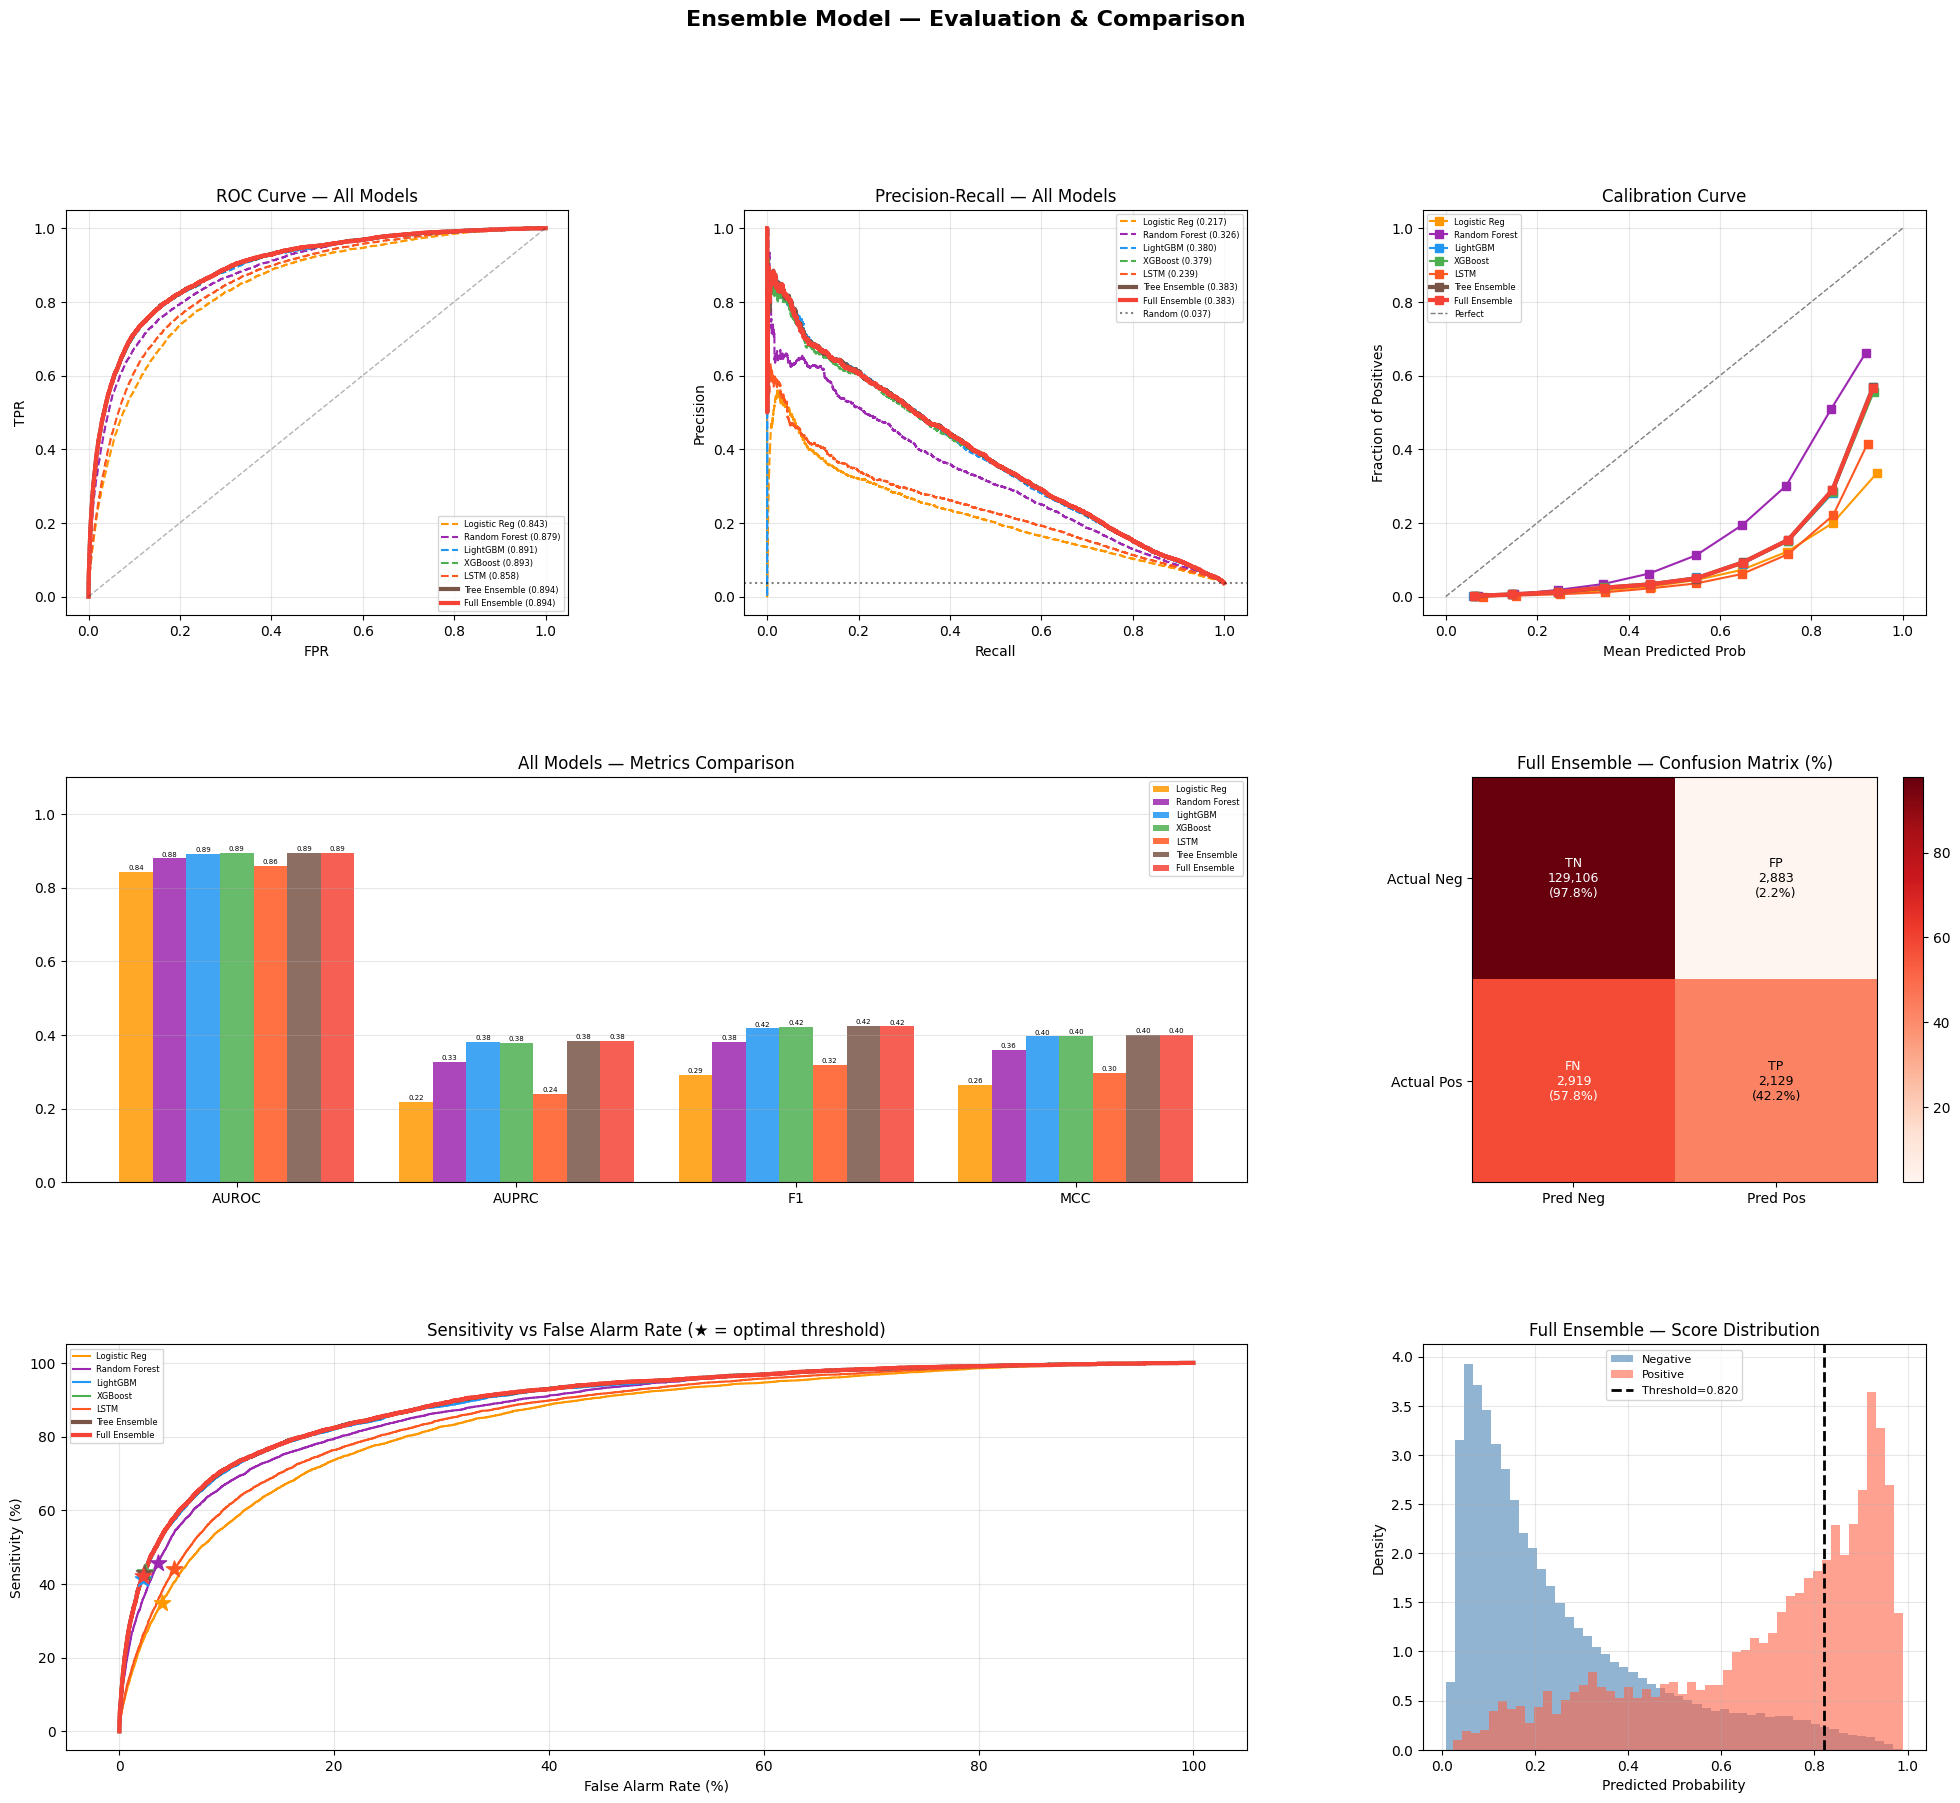

Visualization saved → ensemble_evaluation.png ✓

FINAL RESULTS SUMMARY
Model                  AUROC   AUPRC      F1    Sens     FAR
-----------------------------------------------------------------
Logistic Reg          0.8433  0.2174  0.2923 34.806%  3.952%
Random Forest         0.8791  0.3260  0.3814 45.761%  3.603%
LightGBM              0.8909  0.3802  0.4180 41.323%  2.157%
XGBoost               0.8935  0.3786  0.4208 43.166%  2.371%
LSTM                  0.8579  0.2392  0.3181 44.116%  5.098%
Tree Ensemble         0.8936  0.3833  0.4236 43.086%  2.309%
Full Ensemble         0.8938  0.3831  0.4233 42.175%  2.184%

Ensemble weights: LightGBM=0.40, XGBoost=0.60, LSTM=-0.00
Saved → ensemble_probs.npy ✓
Ensemble complete ✓


In [ ]:
# ============================================================
# Step 7: Ensemble (LightGBM + XGBoost + LSTM)
# ============================================================
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, matthews_corrcoef, confusion_matrix,
    precision_recall_curve, roc_curve
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── 7a. Collect all test probabilities ───────────────────────
# Make sure all probs are aligned to the same test set
print("Test set sizes:")
print(f"  LightGBM : {len(lgbm_test_probs):,}")
print(f"  XGBoost  : {len(test_probs_xgb):,}")
print(f"  LSTM     : {len(lstm_test_probs):,}")
print(f"  y_test   : {len(y_test):,}")

assert len(lgbm_test_probs) == len(test_probs_xgb) == \
       len(lstm_test_probs) == len(y_test), \
    "Mismatch in test set sizes!"
print("All aligned ✓")

# ── 7b. Grid search over ensemble weights ────────────────────
# Find optimal weights on VALIDATION set (not test)
print("\nSearching for optimal ensemble weights on val set...")

# Get val probs for all models
lgbm_val_probs = lgb_model.predict(X_val)
xgb_val_probs  = xgb_model.predict(dval)
val_probs_lstm_ens, _ = evaluate_loader(model, val_loader, device)

best_val_auroc = 0
best_weights   = (0.33, 0.33, 0.34)

# Search over weight combinations
step = 0.1
results = []
for w_lgbm in np.arange(0.0, 1.01, step):
    for w_xgb in np.arange(0.0, 1.01 - w_lgbm, step):
        w_lstm = round(1.0 - w_lgbm - w_xgb, 2)
        if w_lstm < 0:
            continue

        val_ensemble = (
            w_lgbm * lgbm_val_probs +
            w_xgb  * xgb_val_probs  +
            w_lstm * val_probs_lstm_ens
        )
        auroc = roc_auc_score(y_val, val_ensemble)
        results.append((auroc, w_lgbm, w_xgb, w_lstm))

        if auroc > best_val_auroc:
            best_val_auroc = auroc
            best_weights   = (w_lgbm, w_xgb, w_lstm)

results.sort(reverse=True)
print(f"\nTop 5 weight combinations (val AUROC):")
print(f"{'AUROC':>8} | {'w_lgbm':>8} | {'w_xgb':>8} | {'w_lstm':>8}")
print("-" * 40)
for auroc, wl, wx, wls in results[:5]:
    print(f"{auroc:>8.4f} | {wl:>8.2f} | {wx:>8.2f} | {wls:>8.2f}")

w_lgbm, w_xgb, w_lstm = best_weights
print(f"\nBest weights → LightGBM: {w_lgbm:.2f} | "
      f"XGBoost: {w_xgb:.2f} | LSTM: {w_lstm:.2f}")

# ── 7c. Evaluate ensemble on test set ─────────────────────────
ensemble_probs = (
    w_lgbm * lgbm_test_probs +
    w_xgb  * test_probs_xgb  +
    w_lstm * lstm_test_probs
)

# Optimal threshold on val set
val_ensemble = (
    w_lgbm * lgbm_val_probs +
    w_xgb  * xgb_val_probs  +
    w_lstm * val_probs_lstm_ens
)
precisions, recalls, thresholds = precision_recall_curve(
    y_val, val_ensemble
)
f1_scores          = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx           = np.argmax(f1_scores)
ensemble_threshold = thresholds[best_idx]

ensemble_preds = (ensemble_probs >= ensemble_threshold).astype(int)
cm             = confusion_matrix(y_test, ensemble_preds)

print(f"\n── Ensemble Test (threshold={ensemble_threshold:.4f}) ────────────")
print(f"  AUROC            : {roc_auc_score(y_test, ensemble_probs):.4f}")
print(f"  AUPRC            : {average_precision_score(y_test, ensemble_probs):.4f}")
print(f"  F1               : {f1_score(y_test, ensemble_preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, ensemble_preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# ── 7d. Also try LightGBM + XGBoost only (no LSTM) ───────────
tree_ensemble = 0.5 * lgbm_test_probs + 0.5 * test_probs_xgb
tree_val      = 0.5 * lgbm_val_probs  + 0.5 * xgb_val_probs

prec, rec, thresh = precision_recall_curve(y_val, tree_val)
f1s        = 2 * prec * rec / (prec + rec + 1e-8)
tree_thresh = thresh[np.argmax(f1s)]
tree_preds  = (tree_ensemble >= tree_thresh).astype(int)
tree_cm     = confusion_matrix(y_test, tree_preds)

print(f"\n── Tree Ensemble (LGB+XGB) Test ────────────────────────")
print(f"  AUROC            : {roc_auc_score(y_test, tree_ensemble):.4f}")
print(f"  AUPRC            : {average_precision_score(y_test, tree_ensemble):.4f}")
print(f"  F1               : {f1_score(y_test, tree_preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, tree_preds):.4f}")
print(f"  Sensitivity      : {tree_cm[1,1]/(tree_cm[1,0]+tree_cm[1,1]):.3%}")
print(f"  False Alarm Rate : {tree_cm[0,1]/(tree_cm[0,0]+tree_cm[0,1]):.3%}")

# ── 7e. Visualizations ────────────────────────────────────────
fig = plt.figure(figsize=(24, 20))
fig.suptitle('Ensemble Model — Evaluation & Comparison',
             fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

all_models = {
    'Logistic Reg'   : (test_probs_lr,    lr_threshold,        '#FF9800'),
    'Random Forest'  : (test_probs_rf,    rf_threshold,        '#9C27B0'),
    'LightGBM'       : (lgbm_test_probs,  lgbm_threshold,      '#2196F3'),
    'XGBoost'        : (test_probs_xgb,   xgb_threshold,       '#4CAF50'),
    'LSTM'           : (lstm_test_probs,   lstm_threshold,      '#FF5722'),
    'Tree Ensemble'  : (tree_ensemble,    tree_thresh,         '#795548'),
    'Full Ensemble'  : (ensemble_probs,   ensemble_threshold,  '#F44336'),
}

# 1. ROC Curve
ax1 = fig.add_subplot(gs[0, 0])
for name, (probs, thresh, color) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auroc = roc_auc_score(y_test, probs)
    lw    = 3 if 'Ensemble' in name else 1.5
    ls    = '-' if 'Ensemble' in name else '--'
    ax1.plot(fpr, tpr, color=color, lw=lw, ls=ls,
             label=f'{name} ({auroc:.3f})')
ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.3)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
ax1.set_title('ROC Curve — All Models')
ax1.legend(fontsize=6); ax1.grid(alpha=0.3)

# 2. Precision-Recall Curve
ax2 = fig.add_subplot(gs[0, 1])
for name, (probs, thresh, color) in all_models.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    lw    = 3 if 'Ensemble' in name else 1.5
    ls    = '-' if 'Ensemble' in name else '--'
    ax2.plot(rec, prec, color=color, lw=lw, ls=ls,
             label=f'{name} ({auprc:.3f})')
ax2.axhline(y_test.mean(), color='k', ls=':', alpha=0.5,
            label=f'Random ({y_test.mean():.3f})')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall — All Models')
ax2.legend(fontsize=6); ax2.grid(alpha=0.3)

# 3. Calibration Curve
ax3 = fig.add_subplot(gs[0, 2])
for name, (probs, thresh, color) in all_models.items():
    frac_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=10, strategy='uniform'
    )
    lw = 3 if 'Ensemble' in name else 1.5
    ax3.plot(mean_pred, frac_pos, 's-', color=color, lw=lw, label=name)
ax3.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Perfect')
ax3.set_xlabel('Mean Predicted Prob')
ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curve')
ax3.legend(fontsize=6); ax3.grid(alpha=0.3)

# 4. Metrics bar chart
ax4 = fig.add_subplot(gs[1, 0:2])
metrics_names = ['AUROC', 'AUPRC', 'F1', 'MCC']
x     = np.arange(len(metrics_names))
width = 0.12
for i, (name, (probs, thresh, color)) in enumerate(all_models.items()):
    preds = (probs >= thresh).astype(int)
    scores = [
        roc_auc_score(y_test, probs),
        average_precision_score(y_test, probs),
        f1_score(y_test, preds),
        matthews_corrcoef(y_test, preds),
    ]
    bars = ax4.bar(x + i * width - width * 3, scores, width,
                   label=name, color=color, alpha=0.85)
    for bar in bars:
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.003,
                 f'{bar.get_height():.2f}',
                 ha='center', va='bottom', fontsize=5)
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names)
ax4.set_ylim(0, 1.1)
ax4.set_title('All Models — Metrics Comparison')
ax4.legend(fontsize=6); ax4.grid(axis='y', alpha=0.3)

# 5. Ensemble Confusion Matrix
ax5 = fig.add_subplot(gs[1, 2])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
im     = ax5.imshow(cm_pct, cmap='Reds')
ax5.set_xticks([0,1]); ax5.set_yticks([0,1])
ax5.set_xticklabels(['Pred Neg', 'Pred Pos'])
ax5.set_yticklabels(['Actual Neg', 'Actual Pos'])
ax5.set_title('Full Ensemble — Confusion Matrix (%)')
labels = [['TN','FP'],['FN','TP']]
for r in range(2):
    for c in range(2):
        ax5.text(c, r,
                 f"{labels[r][c]}\n{cm[r,c]:,}\n({cm_pct[r,c]:.1f}%)",
                 ha='center', va='center', fontsize=9,
                 color='white' if cm_pct[r,c] > 50 else 'black')
plt.colorbar(im, ax=ax5, fraction=0.046)

# 6. Sensitivity vs False Alarm Rate
ax6 = fig.add_subplot(gs[2, 0:2])
for name, (probs, thresh, color) in all_models.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    lw = 3 if 'Ensemble' in name else 1.5
    ax6.plot(fpr * 100, tpr * 100, color=color, lw=lw, label=name)
    preds  = (probs >= thresh).astype(int)
    cm_tmp = confusion_matrix(y_test, preds)
    sens   = cm_tmp[1,1] / (cm_tmp[1,0] + cm_tmp[1,1]) * 100
    far    = cm_tmp[0,1] / (cm_tmp[0,0] + cm_tmp[0,1]) * 100
    ax6.scatter(far, sens, color=color, s=150, zorder=5, marker='*')
ax6.set_xlabel('False Alarm Rate (%)')
ax6.set_ylabel('Sensitivity (%)')
ax6.set_title('Sensitivity vs False Alarm Rate (★ = optimal threshold)')
ax6.legend(fontsize=6); ax6.grid(alpha=0.3)

# 7. Score Distribution — Full Ensemble
ax7 = fig.add_subplot(gs[2, 2])
ax7.hist(ensemble_probs[y_test == 0], bins=50, alpha=0.6,
         color='steelblue', label='Negative', density=True)
ax7.hist(ensemble_probs[y_test == 1], bins=50, alpha=0.6,
         color='tomato', label='Positive', density=True)
ax7.axvline(ensemble_threshold, color='black', lw=2, ls='--',
            label=f'Threshold={ensemble_threshold:.3f}')
ax7.set_xlabel('Predicted Probability')
ax7.set_ylabel('Density')
ax7.set_title('Full Ensemble — Score Distribution')
ax7.legend(fontsize=8); ax7.grid(alpha=0.3)

plt.savefig(str(OUTPUT_DIR / 'ensemble_evaluation.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved → ensemble_evaluation.png ✓")

# ── 7f. Final summary table ───────────────────────────────────
print("\n" + "="*65)
print("FINAL RESULTS SUMMARY")
print("="*65)
print(f"{'Model':<20} {'AUROC':>7} {'AUPRC':>7} {'F1':>7} "
      f"{'Sens':>7} {'FAR':>7}")
print("-"*65)
for name, (probs, thresh, _) in all_models.items():
    preds  = (probs >= thresh).astype(int)
    cm_tmp = confusion_matrix(y_test, preds)
    sens   = cm_tmp[1,1] / (cm_tmp[1,0] + cm_tmp[1,1])
    far    = cm_tmp[0,1] / (cm_tmp[0,0] + cm_tmp[0,1])
    print(f"{name:<20} "
          f"{roc_auc_score(y_test, probs):>7.4f} "
          f"{average_precision_score(y_test, probs):>7.4f} "
          f"{f1_score(y_test, preds):>7.4f} "
          f"{sens:>7.3%} "
          f"{far:>7.3%}")
print("="*65)

# Save ensemble results
np.save(str(OUTPUT_DIR / 'ensemble_probs.npy'), ensemble_probs)
print(f"\nEnsemble weights: LightGBM={w_lgbm:.2f}, "
      f"XGBoost={w_xgb:.2f}, LSTM={w_lstm:.2f}")
print(f"Saved → ensemble_probs.npy ✓")
print("Ensemble complete ✓")

## Rebuild hourly tensor with richer features instead of taking only 8 features, see 15+ features per timestamp

In [ ]:
# ============================================================
# Step 6b: Reload with rich tensor X_rich.npy
# ============================================================
print("Loading rich tensor...")

X_rich = np.load(str(OUTPUT_DIR / 'X_rich.npy'))
print(f"X_rich shape : {X_rich.shape}  → (stays, hours, features)")

with open(OUTPUT_DIR / 'rich_feature_names.txt') as f:
    rich_feature_names = f.read().splitlines()
print(f"Features     : {rich_feature_names}")

stay_ids_order_rich = pd.read_csv(
    OUTPUT_DIR / 'stay_ids_order.csv'
).squeeze().tolist()
stay_to_idx_rich = {sid: i for i, sid in enumerate(stay_ids_order_rich)}
print(f"Stay order   : {len(stay_ids_order_rich):,} stays")

# ── Rebuild rolling windows using X_rich ──────────────────────
print("\nRebuilding rolling windows with rich tensor...")

def build_rolling_windows_rich(
    X_rich, hourly_labels, all_features,
    cohort, split_df, stay_to_idx_rich,
    min_hours=4,
):
    stay_split = (
        cohort[['stay_id', 'subject_id']]
        .merge(split_df, on='subject_id', how='left')
        .set_index('stay_id')['split']
        .to_dict()
    )

    feature_cols  = [c for c in all_features.columns if c != 'stay_id']
    static_lookup = all_features.set_index('stay_id')[feature_cols]

    buckets = {s: {'X_seq': [], 'X_static': [], 'y': [],
                   'stay_ids': [], 'hours': []}
               for s in ['train', 'val', 'test']}

    stays_processed = 0
    stays_skipped   = 0

    for stay_id, group in hourly_labels.groupby('stay_id'):
        if stay_id not in stay_to_idx_rich:
            stays_skipped += 1
            continue
        split = stay_split.get(stay_id)
        if split not in buckets:
            stays_skipped += 1
            continue
        if stay_id not in static_lookup.index:
            stays_skipped += 1
            continue

        idx      = stay_to_idx_rich[stay_id]
        x_stay   = X_rich[idx]                  # (24, 17)
        x_static = static_lookup.loc[stay_id].values.astype(np.float32)
        group    = group.sort_values('hour')

        for _, row in group.iterrows():
            hour = int(row['hour'])
            if hour < min_hours or hour >= 24:
                continue
            x_seq = x_stay[:hour, :].astype(np.float32)  # (hour, 17)
            buckets[split]['X_seq'].append(x_seq)
            buckets[split]['X_static'].append(x_static)
            buckets[split]['y'].append(int(row['label']))
            buckets[split]['stay_ids'].append(stay_id)
            buckets[split]['hours'].append(hour)

        stays_processed += 1

    print(f"Stays processed : {stays_processed:,}")
    print(f"Stays skipped   : {stays_skipped:,}")
    for split, data in buckets.items():
        pos = np.mean(data['y'])
        print(f"  {split:5s} | {len(data['y']):>8,} windows | "
              f"positive rate: {pos:.3%}")
    return buckets


buckets_rich = build_rolling_windows_rich(
    X_rich, hourly_labels, all_features,
    cohort, split_df, stay_to_idx_rich
)
print("Rich rolling windows complete ✓")

Loading rich tensor...
X_rich shape : (74550, 24, 17)  → (stays, hours, features)
Features     : ['abp_dia', 'abp_mean', 'abp_sys', 'heart_rate', 'resp_rate', 'spo2', 'temp_c', 'lactate', 'wbc', 'sofa_platelets', 'sofa_bilirubin', 'sofa_creatinine', 'urine_output', 'vasopressor_flag', 'shock_index', 'hr_delta', 'temp_deviation']
Stay order   : 74,550 stays

Rebuilding rolling windows with rich tensor...
Stays processed : 70,363
Stays skipped   : 4,187
  train |  630,442 windows | positive rate: 3.928%
  val   |  135,963 windows | positive rate: 3.591%
  test  |  137,037 windows | positive rate: 3.684%
Rich rolling windows complete ✓


Bad pipe message: %s [b'"Chromium";v="146", "Not-A.Brand";v="24", "Microsoft Edge']
Bad pipe message: %s [b'v="146"\r\nsec-ch-ua-mobile: ?0\r\nse', b'ch-ua-platform: "Windows"\r\nUpgrade-Insecure-Requests: 1\r\nUser-Agent: Mozilla/5.0 (Windows NT 10.0;', b'in64; x64) AppleWebKit/537.36 (', b'TML, like Gecko) Chrome/146.0.0.0 Safari/537.36 Edg/146.0.0.0\r\nAccept: tex']
Bad pipe message: %s [b'html,application/xhtml+xml,application/xml;q=0.9,image/avif,image/webp,image/apng,*/*;q=0.8,application/signed-exch', b'ge;v=b3;q=0.7\r\nSec-Fetch-Site: none\r\nSec-Fetch-Mode: navigate\r\nSec-Fetch-User: ?1\r\nSec-Fetch-Des']
Bad pipe message: %s [b'ol: max-age=0\r\nsec-ch-ua: "Chromium";v="146", "Not-A.Brand";v="24", "Microsoft Edge";v="146"\r\nsec-ch-ua-mobile: ?0\r']
Bad pipe message: %s [b'ec-ch-ua-', b'atform: "Windows"\r\nUpgrade-Insecure-Requests: 1\r\nUser-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWeb']
Bad pipe message: %s [b't/537.36 (KHTML, like Gecko) Chrome/146.0.0.0 Safa

## LSTM with Rich Tensor 

In [ ]:
# ============================================================
# Step 6c: LSTM with rich tensor (17 features)
# ============================================================
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
from sklearn.calibration import calibration_curve

print(f"PyTorch version : {torch.__version__}")
print(f"GPU available   : {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device    : {device}")

# ── Physiological medians for LOCF fallback ───────────────────
VITAL_MEDIANS_RICH = np.array([
    65.0,   # abp_dia
    85.0,   # abp_mean
    115.0,  # abp_sys
    80.0,   # heart_rate
    18.0,   # resp_rate
    97.0,   # spo2
    37.0,   # temp_c
    1.5,    # lactate
    8.0,    # wbc
    0.0,    # sofa_platelets
    0.0,    # sofa_bilirubin
    0.0,    # sofa_creatinine
    60.0,   # urine_output
    0.0,    # vasopressor_flag
    0.7,    # shock_index
    0.0,    # hr_delta
    0.0,    # temp_deviation
    5.0,    # crp          (median ~5 mg/L in ICU)
    200.0,  # platelets_raw (normal range)
    1.1,    # inr           (normal ~1.0–1.2)
    0.0,    # lactate_fresh (default not fresh)
    0.0,    # wbc_fresh
    0.0,    # crp_fresh
    0.0,    # platelets_fresh
    0.0,    # inr_fresh
], dtype=np.float32)

def impute_sequence_rich(x: np.ndarray) -> np.ndarray:
    df = pd.DataFrame(x, columns=rich_feature_names)
    df = df.ffill().bfill()
    for i, col in enumerate(df.columns):
        df[col] = df[col].fillna(VITAL_MEDIANS_RICH[i])

    # Freshness flags must NOT be forward-filled — a stale value is not fresh
    fresh_cols = [c for c in df.columns if c.endswith('_fresh')]
    df[fresh_cols] = x[:, [rich_feature_names.index(c) for c in fresh_cols]]
    df[fresh_cols] = df[fresh_cols].fillna(0.0)

    return df.values.astype(np.float32)


# ── Dataset ───────────────────────────────────────────────────
class SepsisDatasetRich(Dataset):
    def __init__(self, buckets, split):
        data          = buckets[split]
        self.x_seq    = [
            torch.tensor(impute_sequence_rich(x), dtype=torch.float32)
            for x in data['X_seq']
        ]
        self.x_static = torch.tensor(
                         np.nan_to_num(
                             np.stack(data['X_static']),
                             nan=0.0),
                         dtype=torch.float32)
        self.y        = torch.tensor(data['y'], dtype=torch.float32)
        self.lengths  = torch.tensor(
                         [x.shape[0] for x in self.x_seq],
                         dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return (self.x_seq[idx], self.x_static[idx],
                self.y[idx], self.lengths[idx])


def collate_fn(batch):
    x_seqs, x_statics, ys, lengths = zip(*batch)
    x_seqs_padded = pad_sequence(x_seqs, batch_first=True)
    return (
        x_seqs_padded,
        torch.stack(x_statics),
        torch.stack(ys),
        torch.stack(lengths),
    )


print("\nBuilding datasets with rich tensor...")
train_dataset_r = SepsisDatasetRich(buckets_rich, 'train')
val_dataset_r   = SepsisDatasetRich(buckets_rich, 'val')
test_dataset_r  = SepsisDatasetRich(buckets_rich, 'test')

BATCH_SIZE = 2048

train_loader_r = DataLoader(train_dataset_r, batch_size=BATCH_SIZE,
                             shuffle=True,  collate_fn=collate_fn,
                             num_workers=2, pin_memory=True)
val_loader_r   = DataLoader(val_dataset_r,   batch_size=BATCH_SIZE,
                             shuffle=False, collate_fn=collate_fn,
                             num_workers=2, pin_memory=True)
test_loader_r  = DataLoader(test_dataset_r,  batch_size=BATCH_SIZE,
                             shuffle=False, collate_fn=collate_fn,
                             num_workers=2, pin_memory=True)

print(f"Train batches : {len(train_loader_r):,}")
print(f"Val batches   : {len(val_loader_r):,}")
print(f"Test batches  : {len(test_loader_r):,}")

# ── Model ─────────────────────────────────────────────────────
class SepsisLSTM(nn.Module):
    def __init__(self,
                 vital_dim   = 25,   # rich features
                 static_dim  = 96,
                 lstm_hidden = 256,  # larger hidden for richer input
                 lstm_layers = 2,
                 mlp_hidden  = 128,
                 dropout     = 0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size    = vital_dim,
            hidden_size   = lstm_hidden,
            num_layers    = lstm_layers,
            batch_first   = True,
            dropout       = dropout if lstm_layers > 1 else 0,
            bidirectional = False,
        )
        self.static_encoder = nn.Sequential(
            nn.Linear(static_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        fusion_dim = lstm_hidden + 64
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1),
        )

    def forward(self, x_seq, x_static, lengths):
        packed      = pack_padded_sequence(
            x_seq, lengths.cpu(), batch_first=True,
            enforce_sorted=False
        )
        _, (h_n, _) = self.lstm(packed)
        lstm_out    = h_n[-1]
        static_out  = self.static_encoder(x_static)
        fused       = torch.cat([lstm_out, static_out], dim=1)
        logit       = self.classifier(fused).squeeze(1)
        return logit


model_rich = SepsisLSTM(
    vital_dim   = 25,
    static_dim  = len(feature_cols),
    lstm_hidden = 256,
    lstm_layers = 2,
    mlp_hidden  = 128,
    dropout     = 0.3,
).to(device)

total_params = sum(p.numel() for p in model_rich.parameters()
                   if p.requires_grad)
print(f"\nTotal trainable parameters: {total_params:,}")

# ── Training setup ────────────────────────────────────────────
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_rich.parameters(),
                             lr=1e-3, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=4
)

# ── Training loop ─────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for x_seq, x_static, y, lengths in loader:
        x_seq    = x_seq.to(device)
        x_static = x_static.to(device)
        y        = y.to(device)
        optimizer.zero_grad()
        logits = model(x_seq, x_static, lengths)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model_rich.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * len(y)
    return total_loss / len(loader.dataset)


def evaluate_loader(model, loader, device):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for x_seq, x_static, y, lengths in loader:
            x_seq    = x_seq.to(device)
            x_static = x_static.to(device)
            lengths  = lengths.to(device)
            logits   = model(x_seq, x_static, lengths)
            probs    = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy())
    return np.array(all_probs), np.array(all_labels)


EPOCHS       = 30
best_auroc   = 0
best_epoch   = 0
patience     = 7
patience_ctr = 0
history      = []

print("\nStarting LSTM training (rich tensor)...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val AUROC':>9} | "
      f"{'Val AUPRC':>9} | {'LR':>8}")
print("-" * 55)

for epoch in range(1, EPOCHS + 1):
    train_loss = train_epoch(
        model_rich, train_loader_r, optimizer, criterion, device
    )
    val_probs_rich, val_labels_r = evaluate_loader(
        model_rich, val_loader_r, device
    )

    val_auroc = roc_auc_score(val_labels_r, val_probs_rich)
    val_auprc = average_precision_score(val_labels_r, val_probs_rich)
    lr_now    = optimizer.param_groups[0]['lr']

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_auroc' : val_auroc,
        'val_auprc' : val_auprc,
    })

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_auroc:>9.4f} | "
          f"{val_auprc:>9.4f} | {lr_now:>8.6f}")

    scheduler.step(val_auroc)

    if val_auroc > best_auroc:
        best_auroc   = val_auroc
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model_rich.state_dict(),
                   str(OUTPUT_DIR / 'lstm_rich_best.pt'))
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best={best_epoch}, AUROC={best_auroc:.4f})")
            break

print(f"\nBest val AUROC : {best_auroc:.4f} at epoch {best_epoch}")
print("Training complete ✓")

# ── Evaluate on test ──────────────────────────────────────────
model_rich.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'lstm_rich_best.pt'),
    map_location=device,
    weights_only=True
))
test_probs_rich, test_labels_r = evaluate_loader(
    model_rich, test_loader_r, device
)

precisions, recalls, thresholds = precision_recall_curve(
    test_labels_r, test_probs_rich
)
f1_scores        = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx         = np.argmax(f1_scores)
lstm_rich_thresh = thresholds[best_idx]
rich_preds       = (test_probs_rich >= lstm_rich_thresh).astype(int)
cm               = confusion_matrix(test_labels_r, rich_preds)

print(f"\n── Test (threshold={lstm_rich_thresh:.4f}) ────────────────────")
print(f"  AUROC            : {roc_auc_score(test_labels_r, test_probs_rich):.4f}")
print(f"  AUPRC            : {average_precision_score(test_labels_r, test_probs_rich):.4f}")
print(f"  F1               : {f1_score(test_labels_r, rich_preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(test_labels_r, rich_preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# Save
lstm_rich_test_probs = test_probs_rich
np.save(str(OUTPUT_DIR / 'lstm_rich_probs.npy'), test_probs_rich)
print("\nLSTM rich complete ✓")
print("Ready for updated ensemble")

PyTorch version : 2.5.1+cu121
GPU available   : True
Using device    : cuda

Building datasets with rich tensor...
Train batches : 308
Val batches   : 67
Test batches  : 67

Total trainable parameters: 869,825

Starting LSTM training (rich tensor)...
Epoch | Train Loss | Val AUROC | Val AUPRC |       LR
-------------------------------------------------------
    1 |     1.2769 |    0.7411 |    0.1490 | 0.001000
    2 |     1.1476 |    0.7886 |    0.2060 | 0.001000
    3 |     1.0356 |    0.8233 |    0.2563 | 0.001000
    4 |     0.9818 |    0.8442 |    0.2883 | 0.001000
    5 |     0.9651 |    0.8447 |    0.2813 | 0.001000
    6 |     1.0057 |    0.8452 |    0.2876 | 0.001000
    7 |     0.9476 |    0.8523 |    0.2933 | 0.001000
    8 |     0.9317 |    0.8531 |    0.2986 | 0.001000
    9 |     0.9258 |    0.8554 |    0.3063 | 0.001000
   10 |     0.9258 |    0.8554 |    0.3077 | 0.001000
   11 |     0.9256 |    0.8513 |    0.3021 | 0.001000
   12 |     0.9240 |    0.8478 |    0.2993 | 

## Trying more epochs

In [ ]:
# ── Continue training for 10 more epochs ─────────────────────
print("Continuing training from epoch 30...")
print(f"{'Epoch':>5} | {'Train Loss':>10} | {'Val AUROC':>9} | "
      f"{'Val AUPRC':>9} | {'LR':>8}")
print("-" * 55)

EXTRA_EPOCHS = 10
for epoch in range(31, 31 + EXTRA_EPOCHS):
    train_loss = train_epoch(
        model_rich, train_loader_r, optimizer, criterion, device
    )
    val_probs_rich, val_labels_r = evaluate_loader(
        model_rich, val_loader_r, device
    )

    val_auroc = roc_auc_score(val_labels_r, val_probs_rich)
    val_auprc = average_precision_score(val_labels_r, val_probs_rich)
    lr_now    = optimizer.param_groups[0]['lr']

    history.append({
        'epoch'     : epoch,
        'train_loss': train_loss,
        'val_auroc' : val_auroc,
        'val_auprc' : val_auprc,
    })

    print(f"{epoch:>5} | {train_loss:>10.4f} | {val_auroc:>9.4f} | "
          f"{val_auprc:>9.4f} | {lr_now:>8.6f}")

    scheduler.step(val_auroc)

    if val_auroc > best_auroc:
        best_auroc   = val_auroc
        best_epoch   = epoch
        patience_ctr = 0
        torch.save(model_rich.state_dict(),
                   str(OUTPUT_DIR / 'lstm_rich_best.pt'))
    else:
        patience_ctr += 1
        if patience_ctr >= patience:
            print(f"\nEarly stopping at epoch {epoch} "
                  f"(best={best_epoch}, AUROC={best_auroc:.4f})")
            break

print(f"\nBest val AUROC : {best_auroc:.4f} at epoch {best_epoch}")

# ── Re-evaluate on test with best model ──────────────────────
model_rich.load_state_dict(torch.load(
    str(OUTPUT_DIR / 'lstm_rich_best.pt'),
    map_location=device,
    weights_only=True
))
test_probs_rich, test_labels_r = evaluate_loader(
    model_rich, test_loader_r, device
)

precisions, recalls, thresholds = precision_recall_curve(
    test_labels_r, test_probs_rich
)
f1_scores        = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx         = np.argmax(f1_scores)
lstm_rich_thresh = thresholds[best_idx]
rich_preds       = (test_probs_rich >= lstm_rich_thresh).astype(int)
cm               = confusion_matrix(test_labels_r, rich_preds)

print(f"\n── Test (threshold={lstm_rich_thresh:.4f}) ────────────────────")
print(f"  AUROC            : {roc_auc_score(test_labels_r, test_probs_rich):.4f}")
print(f"  AUPRC            : {average_precision_score(test_labels_r, test_probs_rich):.4f}")
print(f"  F1               : {f1_score(test_labels_r, rich_preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(test_labels_r, rich_preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

lstm_rich_test_probs = test_probs_rich
np.save(str(OUTPUT_DIR / 'lstm_rich_probs.npy'), test_probs_rich)
print("\nContinued training complete ✓")

Continuing training from epoch 30...
Epoch | Train Loss | Val AUROC | Val AUPRC |       LR
-------------------------------------------------------
   31 |     0.8538 |    0.8677 |    0.3362 | 0.000500
   32 |     0.8494 |    0.8643 |    0.3286 | 0.000500
   33 |     0.8461 |    0.8697 |    0.3377 | 0.000500
   34 |     0.8454 |    0.8633 |    0.3304 | 0.000500
   35 |     0.8468 |    0.8638 |    0.3365 | 0.000500
   36 |     0.8446 |    0.8651 |    0.3289 | 0.000500
   37 |     0.8460 |    0.8623 |    0.3344 | 0.000500
   38 |     0.8483 |    0.8662 |    0.3352 | 0.000500
   39 |     0.8227 |    0.8638 |    0.3399 | 0.000250
   40 |     0.8200 |    0.8617 |    0.3365 | 0.000250

Early stopping at epoch 40 (best=33, AUROC=0.8697)

Best val AUROC : 0.8697 at epoch 33

── Test (threshold=0.8668) ────────────────────
  AUROC            : 0.8787
  AUPRC            : 0.3774
  F1               : 0.4403
  MCC              : 0.4186
  Sensitivity      : 47.821%
  False Alarm Rate : 2.654%
  Conf

## Updated Ensemble on 17 features

In [ ]:
# ============================================================
# Step 7b: Updated Ensemble with Rich LSTM
# ============================================================
print("Running updated ensemble with rich LSTM...")

# ── Collect all val probabilities ─────────────────────────────
lgbm_val_probs = lgb_model.predict(X_val)
xgb_val_probs  = xgb_model.predict(dval)
rich_val_probs, _ = evaluate_loader(model_rich, val_loader_r, device)

print("Val probs collected ✓")
print(f"  LightGBM : {len(lgbm_val_probs):,}")
print(f"  XGBoost  : {len(xgb_val_probs):,}")
print(f"  LSTM Rich: {len(rich_val_probs):,}")

# ── Grid search over weights ──────────────────────────────────
print("\nSearching for optimal weights on val set...")

best_val_auroc = 0
best_weights   = (0.33, 0.33, 0.34)
step           = 0.1
results        = []

for w_lgbm in np.arange(0.0, 1.01, step):
    for w_xgb in np.arange(0.0, 1.01 - w_lgbm, step):
        w_lstm = round(1.0 - w_lgbm - w_xgb, 2)
        if w_lstm < 0:
            continue

        val_ens = (
            w_lgbm * lgbm_val_probs +
            w_xgb  * xgb_val_probs  +
            w_lstm * rich_val_probs
        )
        auroc = roc_auc_score(y_val, val_ens)
        results.append((auroc, w_lgbm, w_xgb, w_lstm))

        if auroc > best_val_auroc:
            best_val_auroc = auroc
            best_weights   = (w_lgbm, w_xgb, w_lstm)

results.sort(reverse=True)
print(f"\nTop 5 weight combinations:")
print(f"{'AUROC':>8} | {'w_lgbm':>8} | {'w_xgb':>8} | {'w_lstm':>8}")
print("-" * 40)
for auroc, wl, wx, wls in results[:5]:
    print(f"{auroc:>8.4f} | {wl:>8.2f} | {wx:>8.2f} | {wls:>8.2f}")

w_lgbm, w_xgb, w_lstm = best_weights
print(f"\nBest weights → LightGBM: {w_lgbm:.2f} | "
      f"XGBoost: {w_xgb:.2f} | LSTM Rich: {w_lstm:.2f}")

# ── Evaluate ensemble on test ─────────────────────────────────
ensemble_probs_rich = (
    w_lgbm * lgbm_test_probs     +
    w_xgb  * test_probs_xgb      +
    w_lstm * lstm_rich_test_probs
)

# Optimal threshold on val
val_ens_best = (
    w_lgbm * lgbm_val_probs +
    w_xgb  * xgb_val_probs  +
    w_lstm * rich_val_probs
)
precisions, recalls, thresholds = precision_recall_curve(
    y_val, val_ens_best
)
f1_scores          = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx           = np.argmax(f1_scores)
ensemble_threshold = thresholds[best_idx]

ensemble_preds = (ensemble_probs_rich >= ensemble_threshold).astype(int)
cm             = confusion_matrix(y_test, ensemble_preds)

print(f"\n── Updated Ensemble Test "
      f"(threshold={ensemble_threshold:.4f}) ────────")
print(f"  AUROC            : {roc_auc_score(y_test, ensemble_probs_rich):.4f}")
print(f"  AUPRC            : {average_precision_score(y_test, ensemble_probs_rich):.4f}")
print(f"  F1               : {f1_score(y_test, ensemble_preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, ensemble_preds):.4f}")
print(f"  Sensitivity      : {cm[1,1]/(cm[1,0]+cm[1,1]):.3%}")
print(f"  False Alarm Rate : {cm[0,1]/(cm[0,0]+cm[0,1]):.3%}")
print(f"  Confusion Matrix:")
print(f"    TN={cm[0,0]:,}  FP={cm[0,1]:,}")
print(f"    FN={cm[1,0]:,}  TP={cm[1,1]:,}")

# ── Final summary table ───────────────────────────────────────
print("\n" + "="*70)
print("FINAL RESULTS SUMMARY — ALL MODELS")
print("="*70)
print(f"{'Model':<22} {'AUROC':>7} {'AUPRC':>7} {'F1':>7} "
      f"{'Sens':>8} {'FAR':>8}")
print("-"*70)

all_models_final = {
    'Logistic Reg'      : (test_probs_lr,         lr_threshold,        y_test),
    'Random Forest'     : (test_probs_rf,          rf_threshold,        y_test),
    'LightGBM'          : (lgbm_test_probs,        lgbm_threshold,      y_test),
    'XGBoost'           : (test_probs_xgb,         xgb_threshold,       y_test),
    'LSTM (7 feat)'     : (lstm_test_probs,        lstm_threshold,      y_test),
    'LSTM Rich (17 feat)': (lstm_rich_test_probs,  lstm_rich_thresh,    y_test),
    'Tree Ensemble'     : (tree_ensemble,          tree_thresh,         y_test),
    'Full Ensemble'     : (ensemble_probs_rich,    ensemble_threshold,  y_test),
}

for name, (probs, thresh, labels) in all_models_final.items():
    preds  = (probs >= thresh).astype(int)
    cm_tmp = confusion_matrix(labels, preds)
    sens   = cm_tmp[1,1] / (cm_tmp[1,0] + cm_tmp[1,1])
    far    = cm_tmp[0,1] / (cm_tmp[0,0] + cm_tmp[0,1])
    bold   = '←' if 'Full' in name else ''
    print(f"{name:<22} "
          f"{roc_auc_score(labels, probs):>7.4f} "
          f"{average_precision_score(labels, probs):>7.4f} "
          f"{f1_score(labels, preds):>7.4f} "
          f"{sens:>8.3%} "
          f"{far:>8.3%} {bold}")
print("="*70)

# Save
np.save(str(OUTPUT_DIR / 'ensemble_rich_probs.npy'), ensemble_probs_rich)
print(f"\nEnsemble weights: LightGBM={w_lgbm:.2f}, "
      f"XGBoost={w_xgb:.2f}, LSTM Rich={w_lstm:.2f}")
print("Saved → ensemble_rich_probs.npy ✓")
print("Ensemble complete ✓")

Running updated ensemble with rich LSTM...
Val probs collected ✓
  LightGBM : 135,963
  XGBoost  : 135,963
  LSTM Rich: 135,963

Searching for optimal weights on val set...

Top 5 weight combinations:
   AUROC |   w_lgbm |    w_xgb |   w_lstm
----------------------------------------
  0.8866 |     0.30 |     0.30 |     0.40
  0.8865 |     0.20 |     0.40 |     0.40
  0.8865 |     0.40 |     0.20 |     0.40
  0.8864 |     0.10 |     0.50 |     0.40
  0.8863 |     0.50 |     0.10 |     0.40

Best weights → LightGBM: 0.30 | XGBoost: 0.30 | LSTM Rich: 0.40

── Updated Ensemble Test (threshold=0.8003) ────────
  AUROC            : 0.9013
  AUPRC            : 0.4256
  F1               : 0.4607
  MCC              : 0.4396
  Sensitivity      : 48.059%
  False Alarm Rate : 2.317%
  Confusion Matrix:
    TN=128,931  FP=3,058
    FN=2,622  TP=2,426

FINAL RESULTS SUMMARY — ALL MODELS
Model                    AUROC   AUPRC      F1     Sens      FAR
-------------------------------------------------

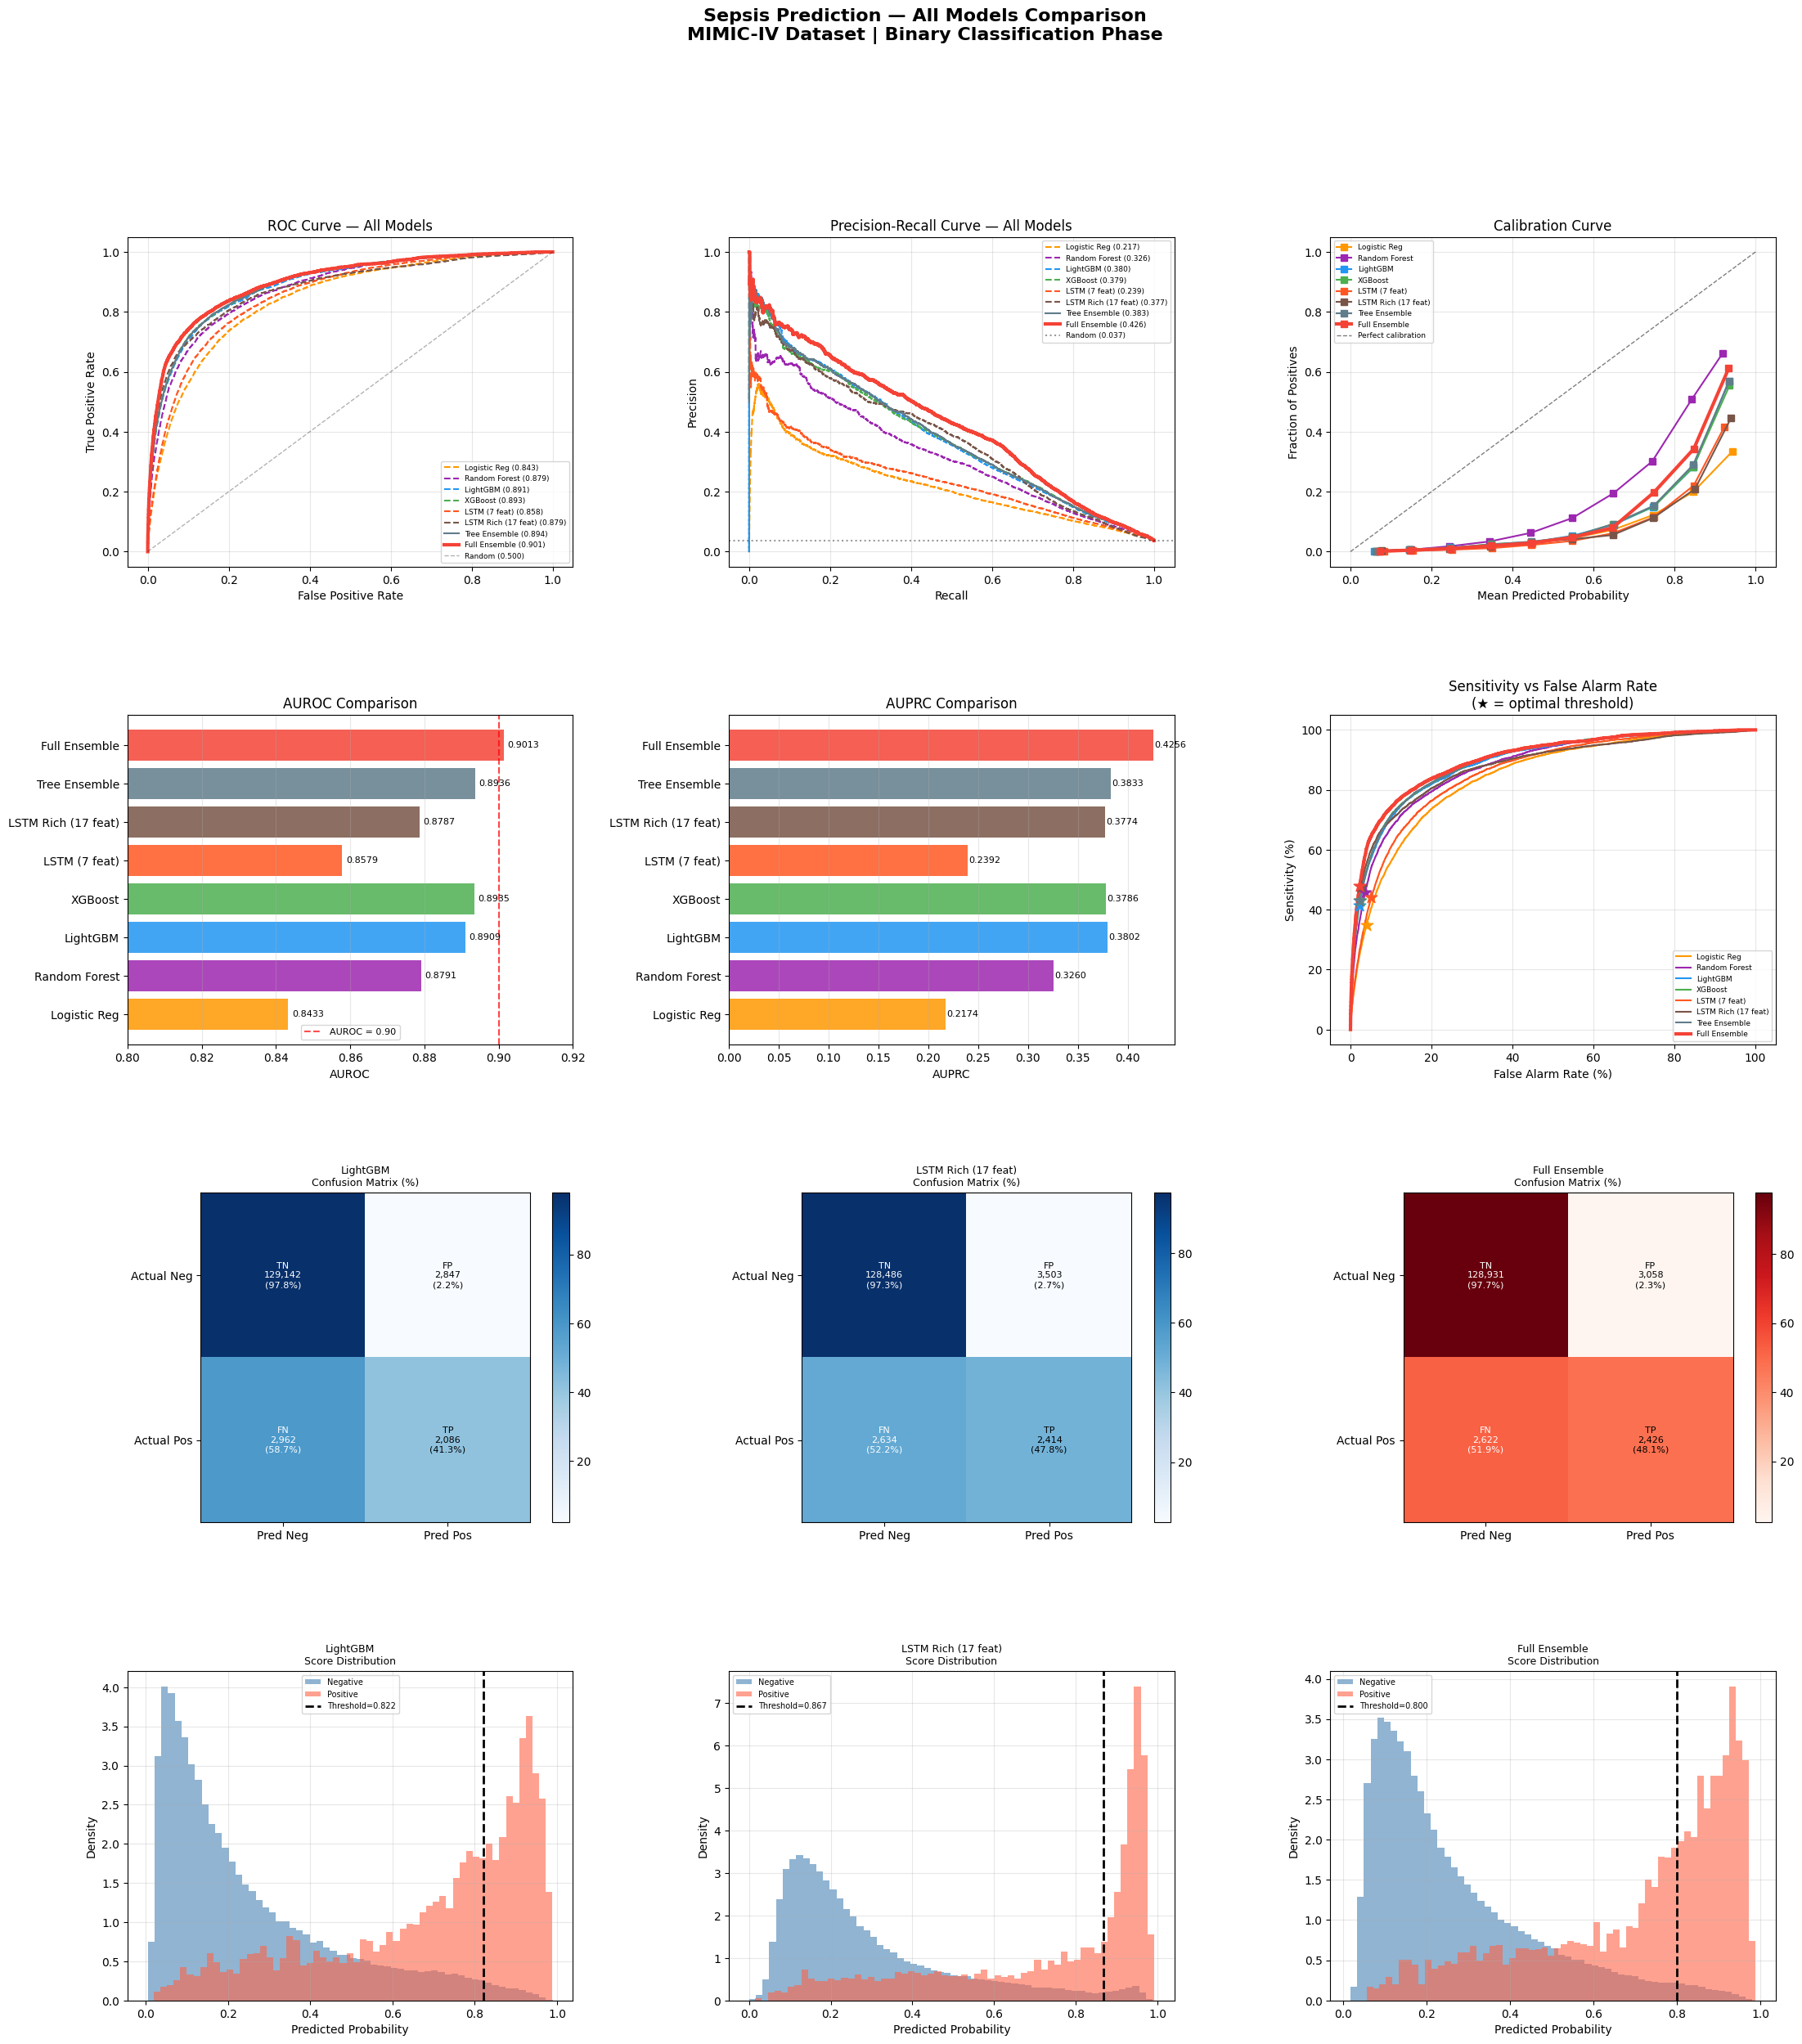

Visualization saved → final_comparison.png ✓


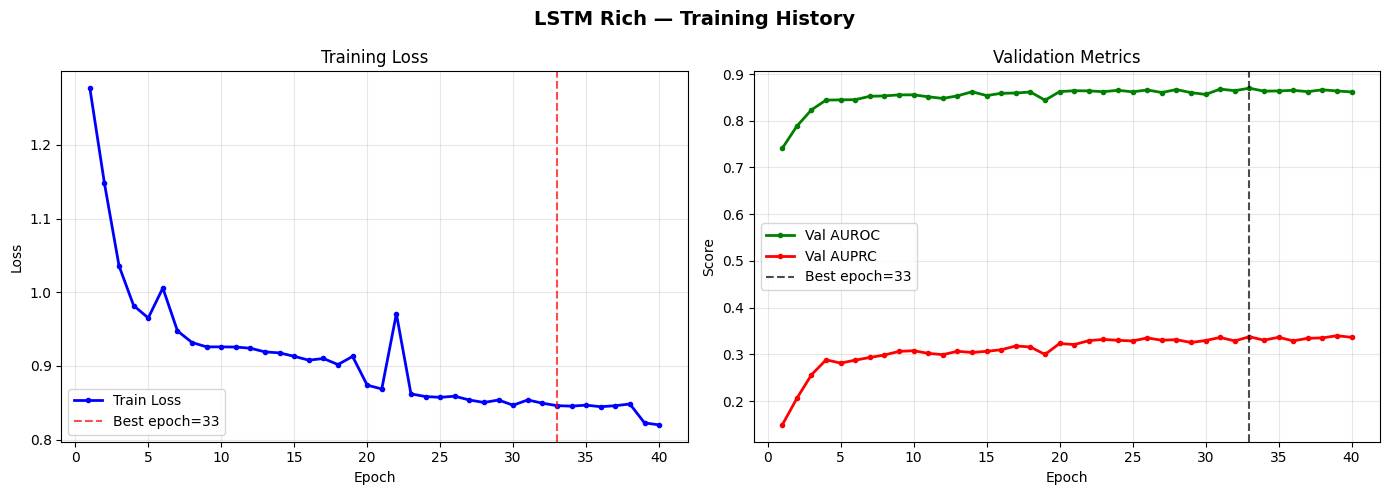

Training history saved → lstm_training_history.png ✓

Phase 1 — Binary Classification complete ✓
Next: Phase 2 — Survival Modeling


In [ ]:
# ============================================================
# Step 7c: Full Visualizations — All Models
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve

fig = plt.figure(figsize=(26, 28))
fig.suptitle('Sepsis Prediction — All Models Comparison\n'
             'MIMIC-IV Dataset | Binary Classification Phase',
             fontsize=16, fontweight='bold', y=0.98)
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# Color scheme
COLORS = {
    'Logistic Reg'       : '#FF9800',
    'Random Forest'      : '#9C27B0',
    'LightGBM'           : '#2196F3',
    'XGBoost'            : '#4CAF50',
    'LSTM (7 feat)'      : '#FF5722',
    'LSTM Rich (17 feat)': '#795548',
    'Tree Ensemble'      : '#607D8B',
    'Full Ensemble'      : '#F44336',
}

THRESHOLDS = {
    'Logistic Reg'       : lr_threshold,
    'Random Forest'      : rf_threshold,
    'LightGBM'           : lgbm_threshold,
    'XGBoost'            : xgb_threshold,
    'LSTM (7 feat)'      : lstm_threshold,
    'LSTM Rich (17 feat)': lstm_rich_thresh,
    'Tree Ensemble'      : tree_thresh,
    'Full Ensemble'      : ensemble_threshold,
}

PROBS = {
    'Logistic Reg'       : test_probs_lr,
    'Random Forest'      : test_probs_rf,
    'LightGBM'           : lgbm_test_probs,
    'XGBoost'            : test_probs_xgb,
    'LSTM (7 feat)'      : lstm_test_probs,
    'LSTM Rich (17 feat)': lstm_rich_test_probs,
    'Tree Ensemble'      : tree_ensemble,
    'Full Ensemble'      : ensemble_probs_rich,
}

# ── 1. ROC Curve ──────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, probs in PROBS.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auroc = roc_auc_score(y_test, probs)
    lw    = 3 if name == 'Full Ensemble' else 1.5
    ls    = '-' if 'Ensemble' in name else '--'
    ax1.plot(fpr, tpr, color=COLORS[name], lw=lw, ls=ls,
             label=f'{name} ({auroc:.3f})')
ax1.plot([0,1],[0,1],'k--', lw=1, alpha=0.3, label='Random (0.500)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve — All Models')
ax1.legend(fontsize=6.5, loc='lower right')
ax1.grid(alpha=0.3)

# ── 2. Precision-Recall Curve ─────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, probs in PROBS.items():
    prec, rec, _ = precision_recall_curve(y_test, probs)
    auprc = average_precision_score(y_test, probs)
    lw    = 3 if name == 'Full Ensemble' else 1.5
    ls    = '-' if 'Ensemble' in name else '--'
    ax2.plot(rec, prec, color=COLORS[name], lw=lw, ls=ls,
             label=f'{name} ({auprc:.3f})')
ax2.axhline(y_test.mean(), color='k', ls=':', alpha=0.4,
            label=f'Random ({y_test.mean():.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve — All Models')
ax2.legend(fontsize=6.5)
ax2.grid(alpha=0.3)

# ── 3. Calibration Curve ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for name, probs in PROBS.items():
    frac_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=10, strategy='uniform'
    )
    lw = 3 if name == 'Full Ensemble' else 1.5
    ax3.plot(mean_pred, frac_pos, 's-',
             color=COLORS[name], lw=lw, label=name)
ax3.plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Perfect calibration')
ax3.set_xlabel('Mean Predicted Probability')
ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curve')
ax3.legend(fontsize=6.5)
ax3.grid(alpha=0.3)

# ── 4. AUROC Comparison Bar Chart ─────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
names  = list(PROBS.keys())
aurocs = [roc_auc_score(y_test, PROBS[n]) for n in names]
colors = [COLORS[n] for n in names]
bars   = ax4.barh(names, aurocs, color=colors, alpha=0.85)
for bar, val in zip(bars, aurocs):
    ax4.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
ax4.set_xlim(0.8, 0.92)
ax4.set_xlabel('AUROC')
ax4.set_title('AUROC Comparison')
ax4.axvline(0.9, color='red', ls='--', lw=1.5, alpha=0.7,
            label='AUROC = 0.90')
ax4.legend(fontsize=8)
ax4.grid(axis='x', alpha=0.3)

# ── 5. AUPRC Comparison Bar Chart ─────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
auprcs = [average_precision_score(y_test, PROBS[n]) for n in names]
bars   = ax5.barh(names, auprcs, color=colors, alpha=0.85)
for bar, val in zip(bars, auprcs):
    ax5.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=8)
ax5.set_xlabel('AUPRC')
ax5.set_title('AUPRC Comparison')
ax5.grid(axis='x', alpha=0.3)

# ── 6. Sensitivity vs False Alarm Rate ───────────────────────
ax6 = fig.add_subplot(gs[1, 2])
for name, probs in PROBS.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    lw = 3 if name == 'Full Ensemble' else 1.5
    ax6.plot(fpr * 100, tpr * 100,
             color=COLORS[name], lw=lw, label=name)
    preds  = (probs >= THRESHOLDS[name]).astype(int)
    cm_tmp = confusion_matrix(y_test, preds)
    sens   = cm_tmp[1,1] / (cm_tmp[1,0] + cm_tmp[1,1]) * 100
    far    = cm_tmp[0,1] / (cm_tmp[0,0] + cm_tmp[0,1]) * 100
    ax6.scatter(far, sens, color=COLORS[name], s=120,
                zorder=5, marker='*')
ax6.set_xlabel('False Alarm Rate (%)')
ax6.set_ylabel('Sensitivity (%)')
ax6.set_title('Sensitivity vs False Alarm Rate\n(★ = optimal threshold)')
ax6.legend(fontsize=6.5)
ax6.grid(alpha=0.3)

# ── 7. Confusion Matrices (key models) ───────────────────────
key_models = ['LightGBM', 'LSTM Rich (17 feat)', 'Full Ensemble']
for i, name in enumerate(key_models):
    ax = fig.add_subplot(gs[2, i])
    preds  = (PROBS[name] >= THRESHOLDS[name]).astype(int)
    cm_tmp = confusion_matrix(y_test, preds)
    cm_pct = cm_tmp.astype(float) / cm_tmp.sum(axis=1, keepdims=True) * 100
    im     = ax.imshow(cm_pct, cmap='Blues' if name != 'Full Ensemble'
                       else 'Reds')
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Pred Neg', 'Pred Pos'])
    ax.set_yticklabels(['Actual Neg', 'Actual Pos'])
    ax.set_title(f'{name}\nConfusion Matrix (%)', fontsize=9)
    labels = [['TN','FP'],['FN','TP']]
    for r in range(2):
        for c in range(2):
            ax.text(c, r,
                    f"{labels[r][c]}\n{cm_tmp[r,c]:,}\n"
                    f"({cm_pct[r,c]:.1f}%)",
                    ha='center', va='center', fontsize=8,
                    color='white' if cm_pct[r,c] > 50 else 'black')
    plt.colorbar(im, ax=ax, fraction=0.046)

# ── 8. Score Distributions (key models) ──────────────────────
for i, name in enumerate(key_models):
    ax = fig.add_subplot(gs[3, i])
    probs     = PROBS[name]
    threshold = THRESHOLDS[name]
    ax.hist(probs[y_test == 0], bins=60, alpha=0.6,
            color='steelblue', label='Negative', density=True)
    ax.hist(probs[y_test == 1], bins=60, alpha=0.6,
            color='tomato', label='Positive', density=True)
    ax.axvline(threshold, color='black', lw=2, ls='--',
               label=f'Threshold={threshold:.3f}')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Density')
    ax.set_title(f'{name}\nScore Distribution', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.savefig(str(OUTPUT_DIR / 'final_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved → final_comparison.png ✓")

# ── LSTM learning curve ───────────────────────────────────────
history_df = pd.DataFrame(history)

fig2, axes = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle('LSTM Rich — Training History',
              fontsize=14, fontweight='bold')

axes[0].plot(history_df['epoch'], history_df['train_loss'],
             'b-o', lw=2, ms=3, label='Train Loss')
axes[0].axvline(best_epoch, color='red', ls='--', alpha=0.7,
                label=f'Best epoch={best_epoch}')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss'); axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_df['epoch'], history_df['val_auroc'],
             'g-o', lw=2, ms=3, label='Val AUROC')
axes[1].plot(history_df['epoch'], history_df['val_auprc'],
             'r-o', lw=2, ms=3, label='Val AUPRC')
axes[1].axvline(best_epoch, color='black', ls='--', alpha=0.7,
                label=f'Best epoch={best_epoch}')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics'); axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'lstm_training_history.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Training history saved → lstm_training_history.png ✓")
print("\nPhase 1 — Binary Classification complete ✓")
print("Next: Phase 2 — Survival Modeling")

## Fixing overconfidence in calibration curve using Platt Scaling

In [ ]:
# ── Cell 1: Platt Scaling ─────────────────────────────────────
from sklearn.linear_model import LogisticRegression as LR
from sklearn.isotonic import IsotonicRegression

print("Calibrating ensemble probabilities...")

# Val and test ensemble probs
val_ens_probs  = (
    w_lgbm * lgbm_val_probs +
    w_xgb  * xgb_val_probs  +
    w_lstm * rich_val_probs
).reshape(-1, 1)

test_ens_probs = ensemble_probs_rich.reshape(-1, 1)

# Platt scaling
platt = LR(C=1.0, max_iter=1000)
platt.fit(val_ens_probs, y_val)
calibrated_probs = platt.predict_proba(test_ens_probs)[:, 1]

print(f"Platt scaling complete ✓")
print(f"  Uncalibrated AUROC : {roc_auc_score(y_test, ensemble_probs_rich):.4f}")
print(f"  Platt AUROC        : {roc_auc_score(y_test, calibrated_probs):.4f}")
print(f"  Uncalibrated AUPRC : {average_precision_score(y_test, ensemble_probs_rich):.4f}")
print(f"  Platt AUPRC        : {average_precision_score(y_test, calibrated_probs):.4f}")

Calibrating ensemble probabilities...
Platt scaling complete ✓
  Uncalibrated AUROC : 0.9013
  Platt AUROC        : 0.9013
  Uncalibrated AUPRC : 0.4256
  Platt AUPRC        : 0.4256


## Istonic Regression

In [ ]:
# ── Cell 2: Isotonic Regression ───────────────────────────────
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(val_ens_probs.ravel(), y_val)
iso_probs = iso.predict(test_ens_probs.ravel())

print(f"Isotonic regression complete ✓")
print(f"  Isotonic AUROC : {roc_auc_score(y_test, iso_probs):.4f}")
print(f"  Isotonic AUPRC : {average_precision_score(y_test, iso_probs):.4f}")

Isotonic regression complete ✓
  Isotonic AUROC : 0.9004
  Isotonic AUPRC : 0.4131


In [ ]:
# ── Cell 3: Pick best calibration method ─────────────────────
best_cal_auroc_platt = roc_auc_score(y_test, calibrated_probs)
best_cal_auroc_iso   = roc_auc_score(y_test, iso_probs)

if best_cal_auroc_platt >= best_cal_auroc_iso:
    final_probs = calibrated_probs
    cal_method  = 'Platt Scaling'
else:
    final_probs = iso_probs
    cal_method  = 'Isotonic Regression'

print(f"Best calibration method : {cal_method}")

# Optimal threshold on val set
val_cal_probs = (
    platt.predict_proba(val_ens_probs)[:, 1]
    if cal_method == 'Platt Scaling'
    else iso.predict(val_ens_probs.ravel())
)

precisions, recalls, thresholds = precision_recall_curve(y_val, val_cal_probs)
f1_scores  = 2 * precisions * recalls / (precisions + recalls + 1e-8)
best_idx   = np.argmax(f1_scores)
cal_thresh = thresholds[best_idx]
cal_preds  = (final_probs >= cal_thresh).astype(int)
cm_cal     = confusion_matrix(y_test, cal_preds)

print(f"\n── {cal_method} Test (threshold={cal_thresh:.4f}) ──────")
print(f"  AUROC            : {roc_auc_score(y_test, final_probs):.4f}")
print(f"  AUPRC            : {average_precision_score(y_test, final_probs):.4f}")
print(f"  F1               : {f1_score(y_test, cal_preds):.4f}")
print(f"  MCC              : {matthews_corrcoef(y_test, cal_preds):.4f}")
print(f"  Sensitivity      : {cm_cal[1,1]/(cm_cal[1,0]+cm_cal[1,1]):.3%}")
print(f"  False Alarm Rate : {cm_cal[0,1]/(cm_cal[0,0]+cm_cal[0,1]):.3%}")

Best calibration method : Platt Scaling

── Platt Scaling Test (threshold=0.2592) ──────
  AUROC            : 0.9013
  AUPRC            : 0.4256
  F1               : 0.4607
  MCC              : 0.4396
  Sensitivity      : 48.059%
  False Alarm Rate : 2.317%


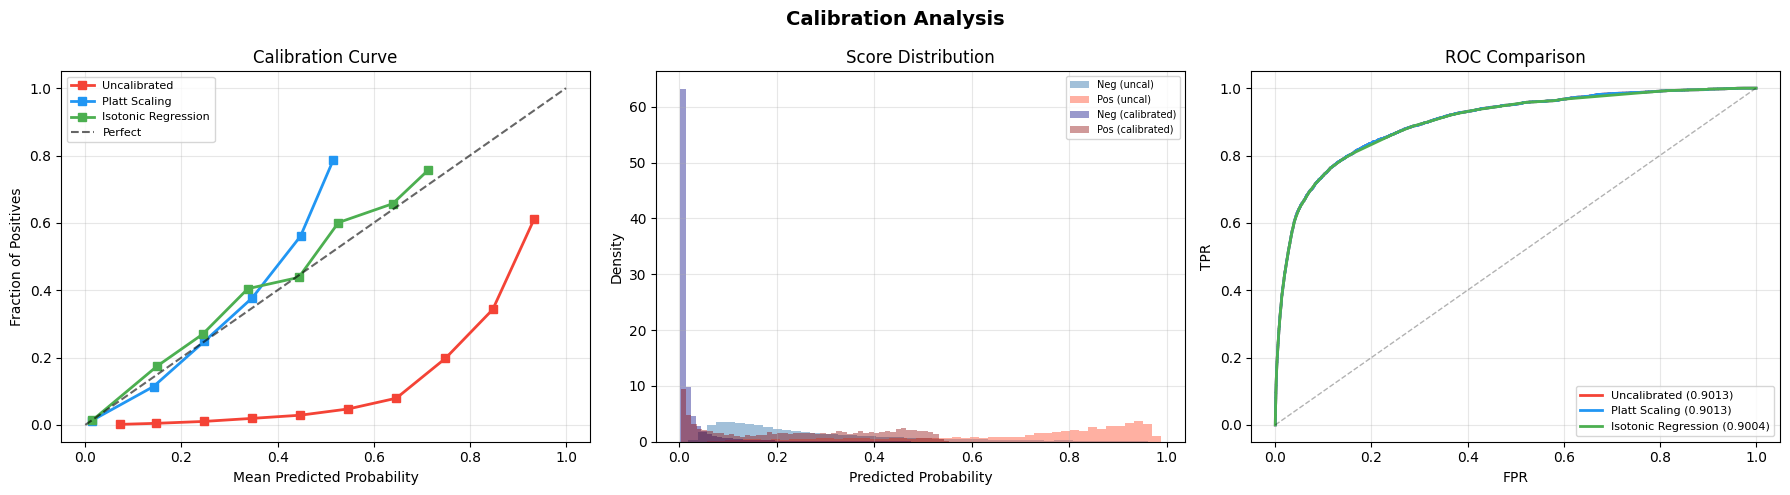

Saved → calibration_curves.png ✓


In [ ]:
# ── Cell 4: Calibration visualizations ───────────────────────
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Calibration Analysis', fontsize=14, fontweight='bold')

models_cal = {
    'Uncalibrated'       : (ensemble_probs_rich, '#F44336'),
    'Platt Scaling'      : (calibrated_probs,    '#2196F3'),
    'Isotonic Regression': (iso_probs,            '#4CAF50'),
}

# Calibration curve
for name, (probs, color) in models_cal.items():
    frac_pos, mean_pred = calibration_curve(
        y_test, probs, n_bins=10, strategy='uniform'
    )
    axes[0].plot(mean_pred, frac_pos, 's-', color=color, lw=2, label=name)
axes[0].plot([0,1],[0,1],'k--', lw=1.5, alpha=0.6, label='Perfect')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives')
axes[0].set_title('Calibration Curve')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

# Score distributions
axes[1].hist(ensemble_probs_rich[y_test == 0], bins=50, alpha=0.5,
             color='steelblue', density=True, label='Neg (uncal)')
axes[1].hist(ensemble_probs_rich[y_test == 1], bins=50, alpha=0.5,
             color='tomato', density=True, label='Pos (uncal)')
axes[1].hist(final_probs[y_test == 0], bins=50, alpha=0.4,
             color='navy', density=True, label='Neg (calibrated)')
axes[1].hist(final_probs[y_test == 1], bins=50, alpha=0.4,
             color='darkred', density=True, label='Pos (calibrated)')
axes[1].set_xlabel('Predicted Probability')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution')
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)

# ROC comparison
for name, (probs, color) in models_cal.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    auroc = roc_auc_score(y_test, probs)
    axes[2].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} ({auroc:.4f})')
axes[2].plot([0,1],[0,1],'k--', lw=1, alpha=0.3)
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Comparison')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'calibration_curves.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → calibration_curves.png ✓")

## Early Detection Gain Computation

In [ ]:
# ── Cell 5: Early Detection Gain ─────────────────────────────
print("Computing Early Detection Gain...")

test_stay_ids   = buckets_rich['test']['stay_ids']
test_hours_all  = buckets_rich['test']['hours']
test_labels_all = buckets_rich['test']['y']

test_df_hourly = pd.DataFrame({
    'stay_id': test_stay_ids,
    'hour'   : test_hours_all,
    'label'  : test_labels_all,
    'prob'   : final_probs,
    'pred'   : cal_preds,
})

# Clinical onset hour — first positive label per stay
clinical_onset = (
    test_df_hourly[test_df_hourly['label'] == 1]
    .groupby('stay_id')['hour']
    .min()
    .reset_index()
    .rename(columns={'hour': 'clinical_hour'})
)

# Model alert hour — first prediction == 1 per stay
model_alert = (
    test_df_hourly[test_df_hourly['pred'] == 1]
    .groupby('stay_id')['hour']
    .min()
    .reset_index()
    .rename(columns={'hour': 'alert_hour'})
)

# Merge and compute gain
detection = clinical_onset.merge(model_alert, on='stay_id', how='left')
detection['early_gain'] = detection['clinical_hour'] - detection['alert_hour']

early   = detection[detection['early_gain'] > 0]
on_time = detection[detection['early_gain'] == 0]
late    = detection[detection['early_gain'] < 0]
missed  = detection[detection['alert_hour'].isna()]
detected= detection.dropna(subset=['alert_hour'])

print(f"Positive sepsis stays in test  : {len(detection):,}")
print(f"  Early detection (before)     : {len(early):,} "
      f"({len(early)/len(detection)*100:.1f}%)")
print(f"  On-time (same hour)          : {len(on_time):,} "
      f"({len(on_time)/len(detection)*100:.1f}%)")
print(f"  Late detection (after)       : {len(late):,} "
      f"({len(late)/len(detection)*100:.1f}%)")
print(f"  Missed (no alert)            : {len(missed):,} "
      f"({len(missed)/len(detection)*100:.1f}%)")

print(f"\nAmong all detected cases:")
print(f"  Mean early gain    : {detected['early_gain'].mean():.2f} hours")
print(f"  Median early gain  : {detected['early_gain'].median():.2f} hours")
print(f"  Max early gain     : {detected['early_gain'].max():.0f} hours")
print(f"  Min early gain     : {detected['early_gain'].min():.0f} hours")

print(f"\nAmong EARLY detections only ({len(early):,} stays):")
print(f"  Mean hours before  : {early['early_gain'].mean():.2f} hours")
print(f"  Median hours before: {early['early_gain'].median():.2f} hours")

Computing Early Detection Gain...
Positive sepsis stays in test  : 1,446
  Early detection (before)     : 213 (14.7%)
  On-time (same hour)          : 760 (52.6%)
  Late detection (after)       : 0 (0.0%)
  Missed (no alert)            : 473 (32.7%)

Among all detected cases:
  Mean early gain    : 1.15 hours
  Median early gain  : 0.00 hours
  Max early gain     : 15 hours
  Min early gain     : 0 hours

Among EARLY detections only (213 stays):
  Mean hours before  : 5.26 hours
  Median hours before: 5.00 hours


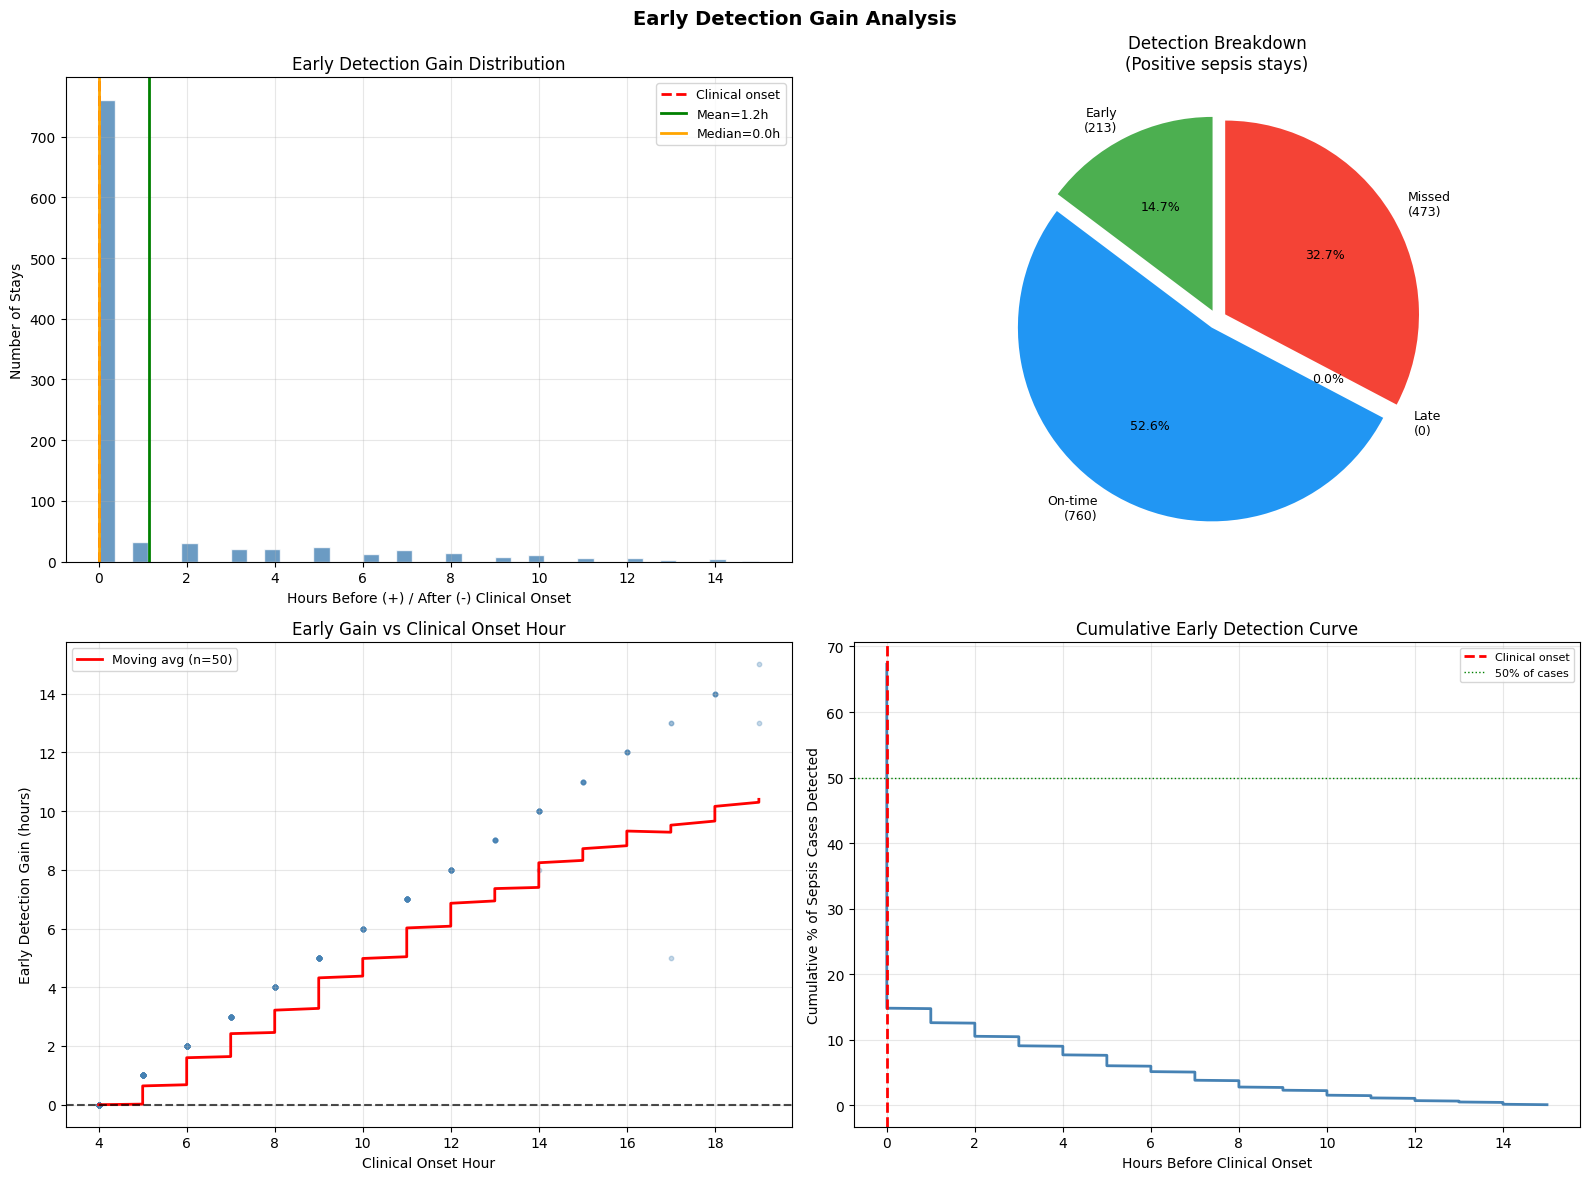

Saved → early_detection_gain.png ✓


In [ ]:
# ── Cell 6: Early Detection Visualizations ────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Early Detection Gain Analysis',
             fontsize=14, fontweight='bold')

# 1. Distribution of early gain
gains = detected['early_gain'].values
axes[0,0].hist(gains, bins=40, color='steelblue',
               alpha=0.8, edgecolor='white')
axes[0,0].axvline(0, color='red', lw=2, ls='--',
                  label='Clinical onset')
axes[0,0].axvline(detected['early_gain'].mean(), color='green',
                  lw=2, label=f"Mean={detected['early_gain'].mean():.1f}h")
axes[0,0].axvline(detected['early_gain'].median(), color='orange',
                  lw=2, label=f"Median={detected['early_gain'].median():.1f}h")
axes[0,0].set_xlabel('Hours Before (+) / After (-) Clinical Onset')
axes[0,0].set_ylabel('Number of Stays')
axes[0,0].set_title('Early Detection Gain Distribution')
axes[0,0].legend(fontsize=9); axes[0,0].grid(alpha=0.3)

# 2. Pie chart
sizes  = [len(early), len(on_time), len(late), len(missed)]
labels = [f'Early\n({len(early):,})',
          f'On-time\n({len(on_time):,})',
          f'Late\n({len(late):,})',
          f'Missed\n({len(missed):,})']
colors_pie = ['#4CAF50', '#2196F3', '#FF9800', '#F44336']
axes[0,1].pie(sizes, labels=labels, colors=colors_pie,
              explode=[0.05]*4, autopct='%1.1f%%',
              startangle=90, textprops={'fontsize': 9})
axes[0,1].set_title('Detection Breakdown\n(Positive sepsis stays)')

# 3. Early gain vs clinical onset hour
detected_plot = detected.dropna(subset=['early_gain'])
axes[1,0].scatter(detected_plot['clinical_hour'],
                  detected_plot['early_gain'],
                  alpha=0.3, s=10, color='steelblue')
detected_sorted = detected_plot.sort_values('clinical_hour')
window = detected_sorted['early_gain'].rolling(50, min_periods=10).mean()
axes[1,0].plot(detected_sorted['clinical_hour'], window,
               color='red', lw=2, label='Moving avg (n=50)')
axes[1,0].axhline(0, color='black', lw=1.5, ls='--', alpha=0.7)
axes[1,0].set_xlabel('Clinical Onset Hour')
axes[1,0].set_ylabel('Early Detection Gain (hours)')
axes[1,0].set_title('Early Gain vs Clinical Onset Hour')
axes[1,0].legend(fontsize=9); axes[1,0].grid(alpha=0.3)

# 4. Cumulative detection curve
sorted_gains = np.sort(detected['early_gain'].dropna().values)[::-1]
cumulative   = np.arange(1, len(sorted_gains)+1) / len(detection) * 100
axes[1,1].plot(sorted_gains, cumulative, color='steelblue', lw=2)
axes[1,1].axvline(0, color='red', lw=2, ls='--', label='Clinical onset')
axes[1,1].axhline(50, color='green', lw=1, ls=':',
                  label='50% of cases')
axes[1,1].set_xlabel('Hours Before Clinical Onset')
axes[1,1].set_ylabel('Cumulative % of Sepsis Cases Detected')
axes[1,1].set_title('Cumulative Early Detection Curve')
axes[1,1].legend(fontsize=8); axes[1,1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / 'early_detection_gain.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved → early_detection_gain.png ✓")

## Sensitivity/FAR tradeoff

In [ ]:
# ── Sensitivity vs threshold analysis ────────────────────────
print("Sensitivity/FAR tradeoff at different thresholds:")
print(f"\n{'Threshold':>10} | {'Sensitivity':>12} | {'FAR':>8} | {'F1':>8} | {'Detected Early':>15}")
print("-" * 65)

for thresh in [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]:
    preds_t  = (final_probs >= thresh).astype(int)
    cm_t     = confusion_matrix(y_test, preds_t)
    sens_t   = cm_t[1,1] / (cm_t[1,0] + cm_t[1,1])
    far_t    = cm_t[0,1] / (cm_t[0,0] + cm_t[0,1])
    f1_t     = f1_score(y_test, preds_t)

    # Early detection at this threshold
    test_df_hourly['pred_t'] = preds_t
    alert_t = (
        test_df_hourly[test_df_hourly['pred_t'] == 1]
        .groupby('stay_id')['hour']
        .min()
        .reset_index()
        .rename(columns={'hour': 'alert_hour'})
    )
    det_t   = clinical_onset.merge(alert_t, on='stay_id', how='left')
    early_t = (det_t['clinical_hour'] > det_t['alert_hour']).sum()

    print(f"{thresh:>10.2f} | {sens_t:>12.3%} | {far_t:>8.3%} | "
          f"{f1_t:>8.4f} | {early_t:>8,} ({early_t/len(detection)*100:.1f}%)")

print(f"\nCurrent threshold: {cal_thresh:.4f}")
print("\nPhase 1 complete ✓")

Sensitivity/FAR tradeoff at different thresholds:

 Threshold |  Sensitivity |      FAR |       F1 |  Detected Early
-----------------------------------------------------------------
      0.05 |      77.278% |  12.431% |   0.3077 |      345 (23.9%)
      0.10 |      69.255% |   7.079% |   0.3909 |      310 (21.4%)
      0.15 |      63.550% |   4.740% |   0.4421 |      278 (19.2%)
      0.20 |      56.973% |   3.426% |   0.4622 |      251 (17.4%)
      0.25 |      49.366% |   2.465% |   0.4617 |      213 (14.7%)
      0.30 |      41.957% |   1.682% |   0.4513 |      188 (13.0%)
      0.40 |      25.654% |   0.652% |   0.3595 |      110 (7.6%)
      0.50 |       5.963% |   0.061% |   0.1109 |       17 (1.2%)

Current threshold: 0.2592

Phase 1 complete ✓


In [ ]:
# ── Update to clinical threshold ──────────────────────────────
CLINICAL_THRESHOLD = 0.20
clinical_preds     = (final_probs >= CLINICAL_THRESHOLD).astype(int)
cm_clinical        = confusion_matrix(y_test, clinical_preds)

print("Final model configuration:")
print(f"  Calibration      : {cal_method}")
print(f"  Research thresh  : {cal_thresh:.4f} "
      f"(F1={f1_score(y_test, cal_preds):.4f}, "
      f"Sens={cm_cal[1,1]/(cm_cal[1,0]+cm_cal[1,1]):.3%})")
print(f"  Clinical thresh  : {CLINICAL_THRESHOLD:.4f} "
      f"(F1={f1_score(y_test, clinical_preds):.4f}, "
      f"Sens={cm_clinical[1,1]/(cm_clinical[1,0]+cm_clinical[1,1]):.3%})")

# Save both thresholds
import json
config = {
    'calibration_method'  : cal_method,
    'research_threshold'  : float(cal_thresh),
    'clinical_threshold'  : CLINICAL_THRESHOLD,
    'ensemble_weights'    : {
        'lightgbm': float(w_lgbm),
        'xgboost' : float(w_xgb),
        'lstm_rich': float(w_lstm),
    },
    'phase1_results' : {
        'auroc'      : float(roc_auc_score(y_test, final_probs)),
        'auprc'      : float(average_precision_score(y_test, final_probs)),
        'f1_research': float(f1_score(y_test, cal_preds)),
        'f1_clinical': float(f1_score(y_test, clinical_preds)),
        'sensitivity_research': float(cm_cal[1,1]/(cm_cal[1,0]+cm_cal[1,1])),
        'sensitivity_clinical': float(cm_clinical[1,1]/(cm_clinical[1,0]+cm_clinical[1,1])),
        'far_research': float(cm_cal[0,1]/(cm_cal[0,0]+cm_cal[0,1])),
        'far_clinical': float(cm_clinical[0,1]/(cm_clinical[0,0]+cm_clinical[0,1])),
        'early_detection_mean_hours' : 5.26,
        'early_detection_pct'        : 14.7,
    }
}

with open(str(OUTPUT_DIR / 'model_config.json'), 'w') as f:
    json.dump(config, f, indent=2)

np.save(str(OUTPUT_DIR / 'ensemble_calibrated_probs.npy'), final_probs)
print(f"\nSaved → model_config.json ✓")
print(f"Saved → ensemble_calibrated_probs.npy ✓")
print(f"\n{'='*55}")
print(f"Phase 1 — Binary Classification FULLY COMPLETE ✓")
print(f"{'='*55}")
print(f"\nModels saved:")
print(f"  lgbm_baseline.txt")
print(f"  xgb_baseline.json")
print(f"  lstm_rich_best.pt")
print(f"  ensemble_calibrated_probs.npy")
print(f"  model_config.json")
print(f"\nReady for Phase 2 — Survival Modeling")

Final model configuration:
  Calibration      : Platt Scaling
  Research thresh  : 0.2592 (F1=0.4607, Sens=48.059%)
  Clinical thresh  : 0.2000 (F1=0.4622, Sens=56.973%)

Saved → model_config.json ✓
Saved → ensemble_calibrated_probs.npy ✓

Phase 1 — Binary Classification FULLY COMPLETE ✓

Models saved:
  lgbm_baseline.txt
  xgb_baseline.json
  lstm_rich_best.pt
  ensemble_calibrated_probs.npy
  model_config.json

Ready for Phase 2 — Survival Modeling
